# Radiometric detector comparison — Waldmann et al. 2025 (Appendix A), parametrized

This notebook implements the Waldmann et al. 2025 ("Infra-Red Sensor Technology Demonstrator System for
Space Domain Awareness," AMOS 2025) Appendix-A radiometric model (eqs 1–11) **parametrically**, and swaps
between two candidate SWIR detectors — a **reference SWIR sensor** and **SCION-SR** (VISGaAs) — plus a
non-physical **toy model** control, while holding the optical / target / atmosphere scenario fixed. The
point is to isolate each detector's contribution to integrated SNR.

> ## ⚠️ What this is, and what it is NOT
> - **It is NOT a reproduction of the paper.** The paper does not publish its WHI solar spectrum, its
>   MODTRAN atmosphere, or numeric target geometry for its reference targets. Every one of those is
>   replaced here by a **clearly-labelled parametric stand-in** (flagged inline and collected in the
>   final summary). This is a deliberate scoping decision.
> - **The BRDF / solar / atmosphere functional forms are a reasonable *parametrization* of the prompt's
>   description of Appendix A**, not the paper's verbatim equations (which we do not have).
> - **What IS load-bearing is consistency:** the identical scenario is fed to all three detectors, so
>   differences in the output are attributable to the detector (given a common band). (One caveat surfaces in
>   §11 — at realistic daytime sky levels the atmosphere stops being a neutral constant and becomes the
>   dominant differentiator. That is flagged, not hidden.)
> - Detector parameters are read from `configs/detector_configs.json` — **never hardcoded here**. That
>   file is intentionally incomplete for some detectors; the missing-value handling is explicit (§2).

---

## 0. Imports and physical constants

Units are SI internally (metre, watt, second, steradian); wavelength is carried in micrometres where
convenient. Physical constants come from `astropy.constants` (project convention).

In [1]:
import json, os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as const

H  = const.h.si.value      # J s
C  = const.c.si.value      # m/s
KB = const.k_B.si.value    # J/K
SOLAR_CONSTANT = 1361.0    # W/m^2 total solar irradiance at 1 AU
print("constants loaded: h=%.3e J s, c=%.3e m/s, k_B=%.3e J/K" % (H, C, KB))

constants loaded: h=6.626e-34 J s, c=2.998e+08 m/s, k_B=1.381e-23 J/K


## 1. Select the active detector and load its config

Set `ACTIVE_DETECTOR` to one of the keys in `configs/detector_configs.json` (the reference SWIR sensor,
SCION-SR, or the toy model). Everything downstream reads that detector's parameters from the config.

In [2]:
ACTIVE_DETECTOR = "ninox_1280"

CFG_PATH = os.path.join("..", "configs", "detector_configs.json")
if not os.path.exists(CFG_PATH):
    CFG_PATH = os.path.join("configs", "detector_configs.json")   # fallback if run from repo root
CFG = json.load(open(CFG_PATH))
assert ACTIVE_DETECTOR in CFG, f"{ACTIVE_DETECTOR} not in config"

# Display-layer anonymization only (config keys left intact). Competitors are generic;
# SCION-SR keeps its name. Applied to every paper-facing output below.
DISPLAY_NAME = {"ninox_1280": "reference SWIR sensor", "scion_visgaas": "SCION-SR", "toy_model": "toy model"}
print("Loaded", len(CFG), "detectors:", [DISPLAY_NAME[k] for k in CFG])
print("Active:", DISPLAY_NAME[ACTIVE_DETECTOR])

Loaded 3 detectors: ['reference SWIR sensor', 'SCION-SR', 'toy model']
Active: reference SWIR sensor


## 2. Handling missing / inconsistent config values (do not paper over these)

`configs/detector_configs.json` is intentionally incomplete or internally inconsistent in three places.
We handle each explicitly rather than inventing numbers:

- **toy_model has no `qe_peak`, `qe_curve`, or `spectral_range_um` at all.** It *cannot* be run through
  eqs 8–9 without a QE. We do **not** fabricate one. Instead a single named placeholder
  `TOY_MODEL_QE_PLACEHOLDER = 1.0` (flat, whole grid) is used, a loud warning prints when toy_model is
  active, and every toy_model output is labelled **"QE ASSUMED — NOT PHYSICAL."** Its SNR is not
  comparable to the other two.
- **The reference SWIR sensor carries two disjoint noise sets** — `read_noise_paper`/`dark_current_paper`
  (ADU/cts, gain unknown) and `read_noise_datasheet_e`/`dark_current_datasheet_e_p_s` (electrons, vendor
  datasheet, −15 °C). They do **not** reconcile under any single plausible gain (a gain fitting the
  read-noise numbers implies a dark current ~50× below the datasheet). Eq 10 is defined in
  photo-electrons, so we use the **datasheet electron-domain values** and state plainly that the paper's
  ADU-domain numbers could not be used. We do **not** derive a gain to force a fit (see §12).
- **SCION-SR noise numbers are published as upper bounds** ("< 30 e−", "Target < 15 e−/px/s"), not
  measurements. We use them as given but **label them as bounds** in the output.

Also note: **`qe_curve` is `null` for *all three* detectors** — even the reference sensor and SCION-SR give only a scalar
`qe_peak`. So QE(λ) is modelled as **flat at `qe_peak` within the detector's `spectral_range_um`**
(zero outside). That flat-at-peak shape is itself an assumption (real QE rolls off at band edges),
flagged wherever it is used.

In [3]:
TOY_MODEL_QE_PLACEHOLDER = 1.0   # named, non-physical placeholder for toy_model only

def qe_of(det_key, grid_um):
    """QE(lambda) on the grid + a human-readable flag. qe_curve is null for all detectors."""
    d = CFG[det_key]
    qe = np.zeros_like(grid_um)
    if det_key == "toy_model":
        qe[:] = TOY_MODEL_QE_PLACEHOLDER
        return qe, "QE ASSUMED - NOT PHYSICAL (flat %.1f; toy_model has no qe_peak/curve/range)" % TOY_MODEL_QE_PLACEHOLDER
    lo, hi = d["spectral_range_um"]
    qe[(grid_um >= lo) & (grid_um <= hi)] = d["qe_peak"]
    return qe, "flat qe_peak=%.2f within %.2f-%.2f um (qe_curve null -> flat-at-peak assumed)" % (d["qe_peak"], lo, hi)

def noise_params(det_key):
    """Electron-domain read noise / dark current / full well for eq 10, per the §2 policy."""
    d = CFG[det_key]
    if det_key == "ninox_1280":
        return dict(read_e=d["read_noise_datasheet_e"]["hg_typical"],
                    dark_e_s=d["dark_current_datasheet_e_p_s"]["typical"],
                    full_well=d["full_well_e"]["hg"], pitch_um=d["pixel_pitch_um"], bound=False,
                    note="datasheet hg_typical read / typical dark @ -15C; paper ADU-domain numbers NOT reconcilable (see s12)")
    if det_key == "scion_visgaas":
        return dict(read_e=d["read_noise"]["value"], dark_e_s=d["dark_current"]["value"],
                    full_well=d["full_well_e"], pitch_um=d["pixel_pitch_um"], bound=True,
                    note="published as UPPER BOUNDS: read < 30 e-, dark < 15 e-/px/s")
    if det_key == "toy_model":
        return dict(read_e=d["read_noise"]["value"], dark_e_s=d["dark_current"]["value"],
                    full_well=d["full_well_e"], pitch_um=None, bound=False,
                    note="toy_model; QE placeholder makes its SNR non-physical")
    raise KeyError(det_key)

_np = noise_params(ACTIVE_DETECTOR)
print("read noise  : %-8s e-%s" % (_np["read_e"], "  (UPPER BOUND)" if _np["bound"] else ""))
print("dark current: %-8s e-/s%s" % (_np["dark_e_s"], "  (UPPER BOUND)" if _np["bound"] else ""))
print("full well   : %-8s e-" % _np["full_well"])
print("note        :", _np["note"])
if ACTIVE_DETECTOR == "toy_model":
    print("\n" + "!"*72)
    print("!! toy_model selected: QE is a NON-PHYSICAL placeholder (flat 1.0).")
    print("!! Its SNR below is NOT comparable to ninox_1280 / scion_visgaas.")
    print("!"*72)

read noise  : 35       e-
dark current: 2000     e-/s
full well   : 10000    e-
note        : datasheet hg_typical read / typical dark @ -15C; paper ADU-domain numbers NOT reconcilable (see s12)


## 3. Assumed target scenario (PLACEHOLDER geometry — not from the paper)

The paper names four reference targets by class only (1U/12U CubeSats at LEO/MEO/GEO, a Skynet-class GEO)
and publishes **no** numeric area / albedo / radius / range. We assume **one representative, conservative
case — a 1U CubeSat in LEO at ~500 km** — with the placeholder values below. These are **not**
reverse-engineered from the paper's Section-7 SNR results (that would be circular); they are round,
physically plausible numbers, and every result inherits their uncertainty.

The four BRDF components (§5) are: **specular flat panel**, **diffuse body**, **body + Earthshine**,
**specular + Earthshine**. For a *conservative sustained* geometry we set the specular glint OFF
(`specular_alignment = 0`) — a flat-panel glint only points at the observer during a brief flare; the
sustained signal is diffuse. Turning `specular_alignment` up models a glint.

In [4]:
SCEN = dict(
    range_km          = 500.0,   # LEO slant range              [PLACEHOLDER]
    A_body_m2         = 0.01,    # 0.1 x 0.1 m body facet        [PLACEHOLDER]
    A_panel_m2        = 0.06,    # deployed solar-panel area     [PLACEHOLDER]
    albedo_body       = 0.20,    # body diffuse albedo           [PLACEHOLDER]
    albedo_panel      = 0.25,    # panel diffuse/spec albedo     [PLACEHOLDER]
    albedo_earth      = 0.30,    # Earth albedo (Earthshine)     [PLACEHOLDER]
    phase_diffuse     = 0.50,    # diffuse phase-function value   [PLACEHOLDER]
    specular_lobe_sr  = 0.05,    # specular lobe solid angle (sr)[PLACEHOLDER]
    specular_alignment= 0.0,     # 0 = conservative (no glint); >0 models a flare
    earthshine_frac   = 0.30,    # sunlit-Earth solid-angle frac [PLACEHOLDER]
)
print("Scenario: 1U CubeSat, LEO, %.0f km (ALL geometry values are placeholders)" % SCEN["range_km"])

Scenario: 1U CubeSat, LEO, 500 km (ALL geometry values are placeholders)


## 4. Eq 1 — wavelength grid

Uniform grid, `lambda_ref = 1 um`, resolving power `R = 1000` → spacing `dλ = lambda_ref/R = 1 nm`. The
span covers the **union** of all three detectors' `spectral_range_um` (widest is SCION's 0.4–1.7 µm) so
the identical grid works for whichever detector is active.

In [5]:
LAMBDA_REF_UM, R_POWER = 1.0, 1000
dlam_um = LAMBDA_REF_UM / R_POWER
GRID_UM = np.arange(0.4, 1.7 + dlam_um, dlam_um)
lam_m = GRID_UM * 1e-6
print("grid: %.2f-%.2f um, %d points, dlam = %.1f nm" % (GRID_UM[0], GRID_UM[-1], len(GRID_UM), dlam_um*1e3))

grid: 0.40-1.70 um, 1301 points, dlam = 1.0 nm


## 5. Eq 2 — solar irradiance at the spacecraft

Flux at the spacecraft = solar irradiance with **no attenuation before the target** (the target is above
the atmosphere).

> **⚠️ Substitution flagged:** the paper uses a WHI reference solar spectrum. We use a **blackbody at
> T = 5778 K normalized to the solar constant (1361 W/m²)** as a stand-in. This is *not* the real WHI
> curve — it omits Fraunhofer lines and the true UV/IR shape — but it captures the broad envelope, which
> is what a flat-QE, R=1000 comparison needs.

In [6]:
def planck_lambda(lam_m, T):
    return (2*H*C**2) / lam_m**5 / (np.exp(H*C/(lam_m*KB*T)) - 1.0)

T_SUN = 5778.0
_bb   = planck_lambda(lam_m, T_SUN)
_wide = np.linspace(0.15e-6, 6.0e-6, 20000)          # wide grid to normalize the shape to 1361 W/m^2
E_sun_m = SOLAR_CONSTANT * _bb / np.trapz(planck_lambda(_wide, T_SUN), _wide)   # W/m^2/m
frac_in_grid = np.trapz(E_sun_m, lam_m) / SOLAR_CONSTANT
print("solar irradiance built (blackbody-WHI proxy); %.1f%% of the 1361 W/m^2 falls in the 0.4-1.7 um grid"
      % (100*frac_in_grid))

solar irradiance built (blackbody-WHI proxy); 79.1% of the 1361 W/m^2 falls in the 0.4-1.7 um grid


## 6. Eqs 3–7 — target BRDF → irradiance at the aperture

Four reflectance components sum to a radiant intensity toward the observer, divided by range² to give
the spectral irradiance at the telescope aperture (pre-atmosphere).

> **⚠️ Functional forms are a parametrization** of the prompt's description of eqs 3–7, not the paper's
> exact equations. Body and panel diffuse are Lambertian; specular is a lobe gated by
> `specular_alignment` (0 here). Earthshine adds a scaled second illumination. All geometry is the §3
> placeholder set.

In [7]:
def brdf_irradiance_at_aperture(E_sun_m, scen):
    rng = scen["range_km"] * 1e3
    inv_r2 = 1.0 / rng**2
    a = scen["specular_alignment"]
    diff_area = scen["albedo_body"]*scen["A_body_m2"] + scen["albedo_panel"]*scen["A_panel_m2"]
    I_diffuse    = E_sun_m * diff_area * scen["phase_diffuse"] / np.pi                       # diffuse body+panel
    I_specular   = E_sun_m * scen["albedo_panel"]*scen["A_panel_m2"] * a / scen["specular_lobe_sr"]  # specular glint (gated)
    E_earth      = E_sun_m * scen["albedo_earth"] * scen["earthshine_frac"]                  # Earthshine illumination
    I_body_earth = E_earth * diff_area * scen["phase_diffuse"] / np.pi                       # body+Earthshine
    I_spec_earth = E_earth * scen["albedo_panel"]*scen["A_panel_m2"] * a / scen["specular_lobe_sr"]  # specular+Earthshine
    terms = dict(diffuse=I_diffuse, specular=I_specular, body_earth=I_body_earth, spec_earth=I_spec_earth)
    E_tgt = (sum(terms.values())) * inv_r2
    return E_tgt, {k: v*inv_r2 for k, v in terms.items()}

E_tgt_m, brdf_terms = brdf_irradiance_at_aperture(E_sun_m, SCEN)
E_tgt_band = np.trapz(E_tgt_m, lam_m)
m_tgt = -26.74 - 2.5*np.log10(E_tgt_band / SOLAR_CONSTANT)     # crude broadband apparent magnitude (sanity only)
print("E_target at aperture, band-integrated 0.4-1.7 um = %.3e W/m^2  (~ apparent mag %.1f)" % (E_tgt_band, m_tgt))
print("BRDF term fractions:", {k: "%.2f" % (np.trapz(v, lam_m)/E_tgt_band) for k, v in brdf_terms.items()})

E_target at aperture, band-integrated 0.4-1.7 um = 1.269e-11 W/m^2  (~ apparent mag 8.3)
BRDF term fractions: {'diffuse': '0.92', 'specular': '0.00', 'body_earth': '0.08', 'spec_earth': '0.00'}


## 7. Atmosphere — a parametric substitute for MODTRAN

The paper does not publish its MODTRAN transmission curve, water column, or aerosol model — only a
descriptive benchmark: **daytime sky radiance in 0.9–1.7 µm is ~20× lower than in the visible**. We build
a deliberately simple parametric atmosphere:

- **Transmission**: flat "windows" at ~1.0, 1.2, 1.6 µm (named in the paper) plus the visible, with a
  reduced floor in the water-absorption gaps. **No fine absorption-line structure.**
- **Sky radiance**: a Rayleigh term ∝ λ⁻⁴. **No Mie/aerosol term and no airglow term** — both are set to
  **zero and flagged as omitted**, not silently folded into the Rayleigh term.

> This is **not** a MODTRAN equivalent. The prompt's stated rationale is that, because the comparison is
> detector-only and the *same* atmosphere is used for every detector, its absolute accuracy is not
> load-bearing — only its consistency across runs is. **That rationale holds only while sky background is
> a sub-dominant noise term.** At realistic *daytime* sky levels (which this benchmark is about) sky
> dominates and the atmosphere becomes the primary differentiator — see §11. A pure λ⁻⁴ shape also can't
> be tuned by normalization to hit exactly 20×; we report the achieved ratio below.

In [8]:
# --- placeholder daytime visible zenith sky radiance; the paper is a DAYTIME SDA benchmark ---
SKY_VIS_REF   = 20.0     # W/m^2/sr/um at lam_vis_ref  [PLACEHOLDER daytime level; absolute value not from paper]
LAM_VIS_REF   = 0.55     # um, visible anchor wavelength

def atm_transmission(grid_um):
    T = np.full_like(grid_um, 0.25)                       # out-of-window floor
    for lo, hi, val in [(0.4,0.7,0.90),(0.95,1.05,0.90),(1.15,1.25,0.90),(1.5,1.7,0.88)]:
        T[(grid_um>=lo)&(grid_um<=hi)] = val
    return T

def sky_radiance_m(grid_um, L_vis=SKY_VIS_REF):
    L_per_um = L_vis * (grid_um/LAM_VIS_REF)**-4.0        # Rayleigh lambda^-4 (Mie=0, airglow=0)
    return L_per_um * 1e6                                 # -> W/m^2/sr/m

T_atm    = atm_transmission(GRID_UM)
L_sky_m  = sky_radiance_m(GRID_UM)

def _band_int(arr, lo, hi):
    m = (GRID_UM>=lo)&(GRID_UM<=hi); return np.trapz(arr[m], lam_m[m])
sky_ratio = _band_int(L_sky_m,0.4,0.7) / _band_int(L_sky_m,0.9,1.7)
print("atmosphere: transmission windows + lambda^-4 sky (Mie=0, airglow=0)")
print("achieved SWIR(0.9-1.7)/visible(0.4-0.7) band-integrated sky ratio = %.1fx  (paper benchmark ~20x)" % sky_ratio)

atmosphere: transmission windows + lambda^-4 sky (Mie=0, airglow=0)
achieved SWIR(0.9-1.7)/visible(0.4-0.7) band-integrated sky ratio = 10.9x  (paper benchmark ~20x)


## 8. Eqs 8–9 — optics, collected power, photon rate

Telescope from the paper's Table 1: **0.7 m aperture, f/6.5, 4540 mm focal length**, 3-surface
protected-aluminium mirror train.

> **⚠️ Assumptions flagged:** mirror reflectance ~0.98/surface → **~0.94 for 3 surfaces** (the paper
> doesn't publish an exact coefficient); aperture treated as **unobstructed** (secondary obscuration not
> published).

In [9]:
D_APERTURE_M   = 0.7
A_TEL          = np.pi*(D_APERTURE_M/2)**2      # unobstructed [ASSUMED no central obscuration]
FOCAL_LENGTH_M = 4.540
TAU_OPTICS     = 0.98**3                        # 3 protected-Al surfaces @ ~0.98 [ASSUMED]
print("aperture area = %.4f m^2, optics throughput (3x0.98) = %.3f" % (A_TEL, TAU_OPTICS))

def _passband_mask(lo_cut_um):
    """Longpass wavelength mask on GRID_UM: 1 where lambda >= lo_cut_um, else 0.
    lo_cut_um=None -> all ones (no cutoff), so existing full-band calls are byte-for-byte unchanged."""
    if lo_cut_um is None:
        return np.ones_like(GRID_UM)
    return (GRID_UM >= lo_cut_um).astype(float)

def signal_electron_rate(det_key, lo_cut_um=None, qe_override=None):
    """Eq 8-9: source signal electron rate [e-/s], band-limited by the detector's QE(lambda).
    Optional longpass `lo_cut_um` rejects lambda < cutoff (default None = full band, backward-compatible).
    Optional `qe_override` supplies a wavelength-resolved QE array (default None = the flat-at-peak qe_of)."""
    qe = qe_of(det_key, GRID_UM)[0] if qe_override is None else qe_override
    mask   = _passband_mask(lo_cut_um)
    P_lam  = E_tgt_m * A_TEL * TAU_OPTICS * T_atm     # W/m collected at detector (pre-QE)
    S_lam  = P_lam * lam_m/(H*C) * qe * mask          # e-/s/m
    return np.trapz(S_lam, lam_m), S_lam

S_rate, S_lam = signal_electron_rate(ACTIVE_DETECTOR)
print("%s: source signal rate = %.3e e-/s" % (DISPLAY_NAME[ACTIVE_DETECTOR], S_rate))

aperture area = 0.3848 m^2, optics throughput (3x0.98) = 0.941
reference SWIR sensor: source signal rate = 7.051e+06 e-/s


## 9. Eqs 10–11 — noise budget and integrated SNR

Standard CCD/CMOS equation over an integration time `t`, for a point source spread across `n_pix`
pixels:

$$\mathrm{SNR_{int}} = \frac{S_e}{\sqrt{S_e + D_e + B_e + n_\mathrm{pix}\,\sigma_\mathrm{read}^2}}$$

with $S_e$ = source electrons, $D_e$ = dark electrons, $B_e$ = sky-background electrons (all over
`n_pix` and `t`), $\sigma_\mathrm{read}$ = per-pixel read noise.

> **⚠️ Placeholders:** integration time `t = 1 ms` (a bright LEO target in high-gain mode; within all
> detectors' exposure ranges) and `n_pix = 5` (point-source PSF footprint; the optics are roughly
> diffraction-limited). Both are held fixed across detectors.

In [10]:
T_INT_S   = 0.001     # 1 ms integration  [PLACEHOLDER, held fixed across detectors]
N_PIX_PSF = 5         # source PSF footprint in pixels  [PLACEHOLDER]
PITCH_TOY_PLACEHOLDER_UM = 10.0   # toy_model has no pixel_pitch; used ONLY for its sky solid-angle

def run_detector(det_key, sky_vis=SKY_VIS_REF, t=T_INT_S, lo_cut_um=None, E_tgt_override=None, qe_override=None):
    """Full noise budget + integrated SNR for one detector.
    lo_cut_um      : optional longpass cutoff (um); masks BOTH the signal and sky integrals; None = full band.
    E_tgt_override : optional target irradiance array [W/m^2/m]; None = module-global baseline E_tgt_m.
    qe_override    : optional wavelength-resolved QE array; None = the flat-at-peak qe_of (existing behaviour).
    All three default to the original behaviour, so the existing comparison cells are unchanged."""
    qe, qe_flag = (qe_of(det_key, GRID_UM) if qe_override is None
                   else (qe_override, "qe_override (wavelength-resolved QE)"))
    npar = noise_params(det_key)
    pitch_um = npar["pitch_um"] if npar["pitch_um"] is not None else PITCH_TOY_PLACEHOLDER_UM
    mask   = _passband_mask(lo_cut_um)
    E_tgt  = E_tgt_m if E_tgt_override is None else E_tgt_override

    # signal (eq 8-9)
    P_lam  = E_tgt * A_TEL * TAU_OPTICS * T_atm
    S_rate = np.trapz(P_lam * lam_m/(H*C) * qe * mask, lam_m)

    # sky background per pixel (same longpass mask applied to the sky integral)
    omega_pix = (pitch_um*1e-6 / FOCAL_LENGTH_M)**2                 # sr
    L_sky = sky_radiance_m(GRID_UM, sky_vis)
    B_rate_pix = np.trapz(L_sky * A_TEL * omega_pix * TAU_OPTICS * T_atm * lam_m/(H*C) * qe * mask, lam_m)

    # noise budget (eq 10-11)
    S_e     = S_rate * t
    dark_e  = npar["dark_e_s"] * t * N_PIX_PSF
    sky_e   = B_rate_pix * t * N_PIX_PSF
    read_e2 = npar["read_e"]**2 * N_PIX_PSF
    noise   = np.sqrt(S_e + dark_e + sky_e + read_e2)
    snr     = S_e/noise if noise > 0 else 0.0
    terms   = dict(shot=np.sqrt(S_e), dark=np.sqrt(dark_e), sky=np.sqrt(sky_e), read=np.sqrt(read_e2))
    return dict(det=det_key, S_rate=S_rate, S_e=S_e, B_rate_pix=B_rate_pix, snr=snr, terms=terms,
                dominant=max(terms, key=terms.get), full_well=npar["full_well"],
                saturated=(S_e/N_PIX_PSF) > npar["full_well"], qe_flag=qe_flag, note=npar["note"],
                bound=npar["bound"])

R = run_detector(ACTIVE_DETECTOR)
print("=== %s ===" % DISPLAY_NAME[ACTIVE_DETECTOR])
print("signal            : %.3e e-/s  ->  %.1f e- in %.0f ms" % (R["S_rate"], R["S_e"], T_INT_S*1e3))
print("noise terms (e-)  :", {k: round(v,2) for k,v in R["terms"].items()}, " dominant:", R["dominant"])
print("SNR_int           : %.1f" % R["snr"])
print("saturated (>full well %s e-)? %s" % (R["full_well"], R["saturated"]))
if ACTIVE_DETECTOR == "toy_model":
    print(">>> toy_model SNR is NOT PHYSICAL (QE placeholder) <<<")

=== reference SWIR sensor ===
signal            : 7.051e+06 e-/s  ->  7050.7 e- in 1 ms
noise terms (e-)  : {'shot': 83.97, 'dark': 3.16, 'sky': 222.39, 'read': 78.26}  dominant: sky
SNR_int           : 28.2
saturated (>full well 10000 e-)? False


### Per-wavelength noise-budget terms

Signal and sky are spectral (they depend on QE(λ)·T_atm(λ)); dark and read are per-pixel scalars. The
plot shows the **spectral electron-rate densities** for source signal and sky background (what the band
integrals of §9 sum up), with QE(λ)·T_atm(λ) overlaid so you can see *where* in the band the signal
comes from. The scalar dark and read contributions are annotated in the title.

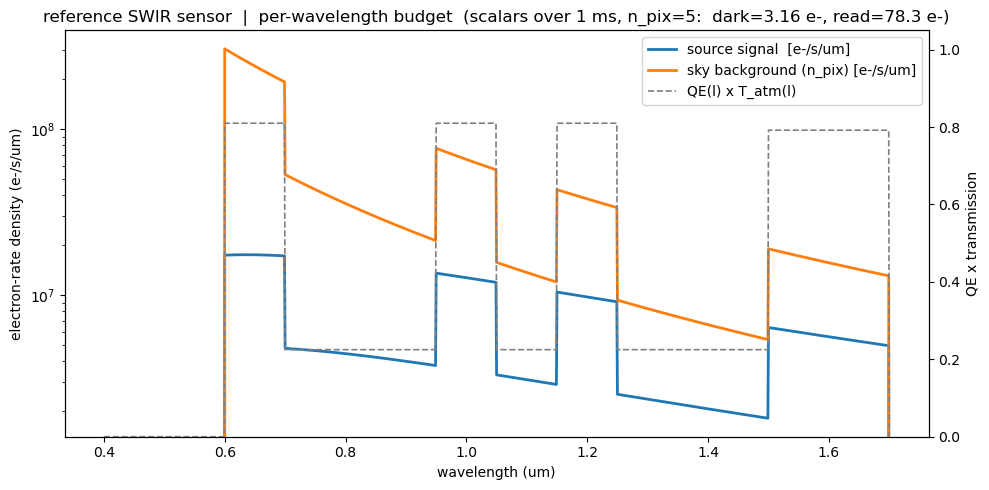

In [11]:
qe_a, _ = qe_of(ACTIVE_DETECTOR, GRID_UM)
npar_a  = noise_params(ACTIVE_DETECTOR)
pitch_a = npar_a["pitch_um"] or PITCH_TOY_PLACEHOLDER_UM
omega_a = (pitch_a*1e-6/FOCAL_LENGTH_M)**2

S_lam_density   = E_tgt_m * A_TEL * TAU_OPTICS * T_atm * lam_m/(H*C) * qe_a * 1e-6            # e-/s/um (source)
sky_lam_density = sky_radiance_m(GRID_UM) * A_TEL*omega_a*TAU_OPTICS*T_atm * lam_m/(H*C) * qe_a * N_PIX_PSF * 1e-6  # e-/s/um (sky, n_pix)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(GRID_UM, S_lam_density,  color="tab:blue",  lw=2, label="source signal  [e-/s/um]")
ax.plot(GRID_UM, sky_lam_density, color="tab:orange", lw=2, label="sky background (n_pix) [e-/s/um]")
ax.set_yscale("log"); ax.set_xlabel("wavelength (um)"); ax.set_ylabel("electron-rate density (e-/s/um)")
ax2 = ax.twinx()
ax2.plot(GRID_UM, qe_a*T_atm, color="0.5", ls="--", lw=1.2, label="QE(l) x T_atm(l)")
ax2.set_ylabel("QE x transmission"); ax2.set_ylim(0, 1.05)
ax.set_title("%s  |  per-wavelength budget  (scalars over %d ms, n_pix=%d:  dark=%.2f e-, read=%.1f e-)"
             % (DISPLAY_NAME[ACTIVE_DETECTOR], T_INT_S*1e3, N_PIX_PSF, R["terms"]["dark"], R["terms"]["read"]))
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="upper right"); plt.tight_layout(); plt.show()

## 10. Comparison table — the two physical detectors, identical scenario

Loop the two physical detectors through the identical fixed scenario and tabulate integrated SNR, source
photon (electron) rate, the dominant noise term, and each budget component. Detector labels are generic
(**SCION-SR**, **reference SWIR sensor**). The toy model is **excluded from this claim-facing table** — its
QE is a non-physical placeholder, not comparable.

In [12]:
rows = []
for k in ("ninox_1280", "scion_visgaas"):     # toy model excluded from this claim-facing table (non-physical QE)
    r = run_detector(k)
    rows.append({
        "detector": DISPLAY_NAME[k],
        "SNR_int": round(r["snr"], 1),
        "signal_e_per_s": "%.2e" % r["S_rate"],
        "dominant_noise": r["dominant"],
        "shot_e": round(r["terms"]["shot"], 1),
        "sky_e": round(r["terms"]["sky"], 1),
        "read_e": round(r["terms"]["read"], 1) if not r["bound"] else "<%.1f" % r["terms"]["read"],
        "dark_e": round(r["terms"]["dark"], 2),
        "saturated": r["saturated"],
        "flag": ("noise = UPPER BOUNDS" if r["bound"] else ""),
    })
table = pd.DataFrame(rows).set_index("detector")
print("Fixed scenario: 1U CubeSat @ 500 km, t=%.0f ms, daytime sky (SKY_VIS_REF=%.0f).  All values inherit the placeholders."
      % (T_INT_S*1e3, SKY_VIS_REF))
table

Fixed scenario: 1U CubeSat @ 500 km, t=1 ms, daytime sky (SKY_VIS_REF=20).  All values inherit the placeholders.


,SNR_int,signal_e_per_s,dominant_noise,shot_e,sky_e,read_e,dark_e,saturated,flag
detector,,,,,,,,,
reference SWIR sensor,28.2,7.05e+06,sky,84.0,222.4,78.3,3.16,False,
SCION-SR,23.2,9.50e+06,sky,97.5,392.5,<67.1,0.27,False,noise = UPPER BOUNDS


**Reading the table — a band-coverage difference, not a detector property (corrected).** At this daytime
sky level the budget is **sky-dominated**, so whichever detector admits the *least* sky posts the higher
SNR. Here the higher SNR belongs to the detector with the **narrower default band** (0.6–1.7 µm, excluding
the bright visible) over the one with the wider 0.4–1.7 µm band — i.e. it is a **band-coverage effect, not
an intrinsic detector advantage**. This earlier interpretation, which credited the detector itself, is
corrected: a fair detector-to-detector comparison must hold the observing **band in common**. Compared at a
common NIR–SWIR band (as the §5 bounding-model section does), the residual difference comes from the
detectors' actual **noise floors** — read noise and dark current — not their default bandpasses. (The toy
model is excluded; its QE is a non-physical placeholder.)

## 11. Sensitivity: the ranking flips between night and day

The prompt's premise — atmosphere absolute level is not load-bearing, only consistency matters — holds
**only when sky is sub-dominant**. Here we re-run at a low (night) sky level and the daytime level to show
the ranking is regime-dependent. This is a finding, not a bug: at realistic daytime sky the atmosphere is
the dominant differentiator, so "detector-only isolation" is only strictly true in the signal/read-limited
(night) regime.

In [13]:
for label, sky in [("NIGHT (sky ~ 0)", 1e-3), ("DAY (placeholder)", SKY_VIS_REF)]:
    line = "  ".join("%s SNR=%5.1f (%s-dom)" % (DISPLAY_NAME[k], run_detector(k, sky_vis=sky)["snr"],
                                                run_detector(k, sky_vis=sky)["dominant"])
                     for k in ("ninox_1280","scion_visgaas"))
    print("%-18s : %s" % (label, line))
print("\nThese two detectors run at their DEFAULT full bands (0.6-1.7 vs 0.4-1.7 um), so the")
print("night/day flip is a BAND-COVERAGE effect (which band admits less visible sky), NOT an")
print("intrinsic detector property. A detector-only comparison requires a common band -- see the")
print("bounding-model section, which fixes the band and varies the detector noise floor.")

NIGHT (sky ~ 0)    : reference SWIR sensor SNR= 61.4 (shot-dom)  SCION-SR SNR= 80.3 (shot-dom)
DAY (placeholder)  : reference SWIR sensor SNR= 28.2 (sky-dom)  SCION-SR SNR= 23.2 (sky-dom)

These two detectors run at their DEFAULT full bands (0.6-1.7 vs 0.4-1.7 um), so the
night/day flip is a BAND-COVERAGE effect (which band admits less visible sky), NOT an
intrinsic detector property. A detector-only comparison requires a common band -- see the
bounding-model section, which fixes the band and varies the detector noise floor.


## 12. Assumptions, placeholders, and the reference-sensor noise discrepancy (summary)

**Every non-paper value introduced, in one place:**

| quantity | value used | status |
|---|---|---|
| Solar spectrum | 5778 K blackbody @ 1361 W/m² | **substitute** for the paper's WHI curve |
| Target geometry (1U LEO) | area 0.01/0.06 m², albedo 0.20/0.25, 500 km, phase 0.5, Earthshine frac 0.30 | **placeholders**, not from paper, not reverse-engineered |
| BRDF functional forms | Lambertian diffuse + gated specular lobe + Earthshine | **parametrization** of eqs 3–7, not verbatim |
| Specular glint | `specular_alignment = 0` (off) | conservative sustained case |
| Atmosphere transmission | flat windows 1.0/1.2/1.6 µm + visible, 0.25 floor | **illustrative**, no line structure |
| Sky radiance | λ⁻⁴ Rayleigh; Mie = 0, airglow = 0 | **omissions flagged**; achieved SWIR/vis ~11× vs paper's ~20× |
| Daytime sky level | `SKY_VIS_REF = 20` W/m²/sr/µm | **placeholder** absolute level (drives §11) |
| Mirror throughput | 0.98³ ≈ 0.94 | **assumed** (paper gives no coefficient) |
| Aperture obscuration | none (unobstructed) | **assumed** |
| Integration time / n_pix | 1 ms / 5 px | **placeholders**, fixed across detectors |
| QE(λ) for the two SWIR detectors | flat `qe_peak` within `spectral_range` | **assumed** (qe_curve null for all) |
| QE(λ) for toy_model | `TOY_MODEL_QE_PLACEHOLDER = 1.0` | **NON-PHYSICAL** placeholder |
| toy_model pixel pitch | 10 µm | **placeholder** (config has none; sky solid-angle only) |

**The reference-sensor ADU-vs-electron discrepancy (open question).** `configs/detector_configs.json`
carries two disjoint noise sets for the reference SWIR sensor:

- **paper (ADU/cts):** read 224.1 ADU (high gain), dark 205.7 cts/s — gain unknown.
- **datasheet (electrons, −15 °C):** read 35 e− (hg typical), dark 2000 e−/s (typical).

These **cannot be reconciled under any single plausible gain**: a gain that maps 224.1 ADU → 35 e−
(≈0.156 e−/ADU) maps 205.7 cts/s → ~32 e−/s dark — roughly **50× below** the datasheet's 2000 e−/s. Since
eq 10 is defined in photo-electrons, this notebook uses the **datasheet electron values** and does **not**
invent a gain to force a fit. The discrepancy is left open and recorded in
`docs/recon/0002-detector-comparison-benchmark.md`.

---
*This notebook is a parametric benchmark, not a paper reproduction. Treat the absolute SNR numbers as
scenario-dependent to within the placeholders above; the load-bearing content is the **relative** detector
behaviour under an identical scenario, with the §11 caveat that at daytime sky levels the atmosphere,
not the detector, dominates.*

---
# SCION-SR daytime-custody demonstration

*(This section is an appendix to the detector comparison above. It does not alter any earlier cell or
output — it reuses the same model functions, now with the optional passband added in Change 1. Target:
support of AMOS paper §5 — ground-based daytime/twilight custody of LEO objects with the SCION-SR
VisGaAs focal plane.)*

We fix `ACTIVE_DETECTOR = "scion_visgaas"` and ask a custody question: **at increasing daytime sky
brightness, does the SCION-SR frame still detect a LEO object above a fixed SNR threshold?** We run a
**baseline** 1U-class object (the conventional ~10 cm LEO catalog threshold) and **one harder geometry**
(a longer 1500 km slant range, i.e. a low-elevation pass), across three sky levels.

> ## ⚠️ Placeholder sky levels — NOT a solar-elevation model
> The three `SKY_VIS_REF` values below are **placeholder visible-sky-radiance levels** chosen to span a
> low→high daytime range. They are **not** mapped to solar elevation, and **no** solar-elevation →
> radiance relation is derived or implied — that (and a real MODTRAN atmosphere) is the deferred
> follow-on. The λ⁻⁴ Rayleigh sky, Mie/aerosol = 0, and airglow = 0 assumptions of §7 all still hold; the
> achieved SWIR/visible sky suppression is ~11× vs the literature ~20×. Treat every absolute SNR here as
> scenario-dependent; the load-bearing content is the **relative** custody behaviour across sky level.

In [14]:
DET        = "scion_visgaas"     # this section is SCION-SR only
ACTIVE_DETECTOR = DET            # (per the demonstration scope; does not affect the cells above)
SNR_DETECT = 5                   # detection criterion (single, named)

# --- targets: baseline uses the module-global E_tgt_m (SCEN @ 500 km); harder = same geometry @ 1500 km ---
SCEN_HARDER = dict(SCEN); SCEN_HARDER["range_km"] = 1500.0     # [PLACEHOLDER harder geometry: low-elev pass]
E_tgt_harder, _ = brdf_irradiance_at_aperture(E_sun_m, SCEN_HARDER)

TARGETS = [
    ("baseline (1U, 500 km)",  None),            # None -> run_detector uses global baseline E_tgt_m
    ("harder (1U, 1500 km)",   E_tgt_harder),
]

# --- three placeholder daytime sky levels (low / mid / high); NO solar-elevation mapping ---
SKY_LEVELS = [2.0, 20.0, 100.0]     # W/m^2/sr/um visible zenith  [PLACEHOLDERS]

def _mag(E):
    return -26.74 - 2.5*np.log10(np.trapz(E if E is not None else E_tgt_m, lam_m)/SOLAR_CONSTANT)
print("SCION-SR daytime custody | SNR_DETECT = %d" % SNR_DETECT)
for name, E in TARGETS:
    print("  %-22s ~ apparent mag %.1f" % (name, _mag(E)))
print("  sky levels (placeholder W/m^2/sr/um):", SKY_LEVELS)

SCION-SR daytime custody | SNR_DETECT = 5
  baseline (1U, 500 km)  ~ apparent mag 8.3
  harder (1U, 1500 km)   ~ apparent mag 10.7
  sky levels (placeholder W/m^2/sr/um): [2.0, 20.0, 100.0]


## Noise budget across sky level (SCION-SR, both targets)

For each (target × sky level): integrated SNR, the four-term noise budget (electrons), and the dominant
term. As the placeholder sky rises, the budget moves from **near-balanced** (shot ≈ sky ≈ read, faint-sky
end) toward **strongly sky-dominated** (bright-sky end) — the daytime-SDA regime the SWIR band is meant to
mitigate. (A fully shot/read-limited regime appears only at still-lower sky; see the continuous axis in
the figures and the night case in §11.)

In [15]:
budget_rows = []
for tname, E in TARGETS:
    for sv in SKY_LEVELS:
        r = run_detector(DET, sky_vis=sv, E_tgt_override=E)     # full band (lo_cut_um=None)
        budget_rows.append({
            "target": tname, "SKY_VIS_REF": sv,
            "SNR_int": round(r["snr"], 1),
            "shot_e": round(r["terms"]["shot"], 1),
            "sky_e":  round(r["terms"]["sky"], 1),
            "read_e": round(r["terms"]["read"], 1),
            "dark_e": round(r["terms"]["dark"], 2),
            "dominant": r["dominant"],
        })
budget_table = pd.DataFrame(budget_rows)
print("SCION-SR full-band noise budget (read noise is an UPPER BOUND per config).")
budget_table

SCION-SR full-band noise budget (read noise is an UPPER BOUND per config).


,target,SKY_VIS_REF,SNR_int,shot_e,sky_e,read_e,dark_e,dominant
0,"baseline (1U, 500 km)",2.0,55.4,97.5,124.1,67.1,0.27,sky
1,"baseline (1U, 500 km)",20.0,23.2,97.5,392.5,67.1,0.27,sky
2,"baseline (1U, 500 km)",100.0,10.7,97.5,877.7,67.1,0.27,sky
3,"harder (1U, 1500 km)",2.0,7.3,32.5,124.1,67.1,0.27,sky
4,"harder (1U, 1500 km)",20.0,2.6,32.5,392.5,67.1,0.27,sky
5,"harder (1U, 1500 km)",100.0,1.2,32.5,877.7,67.1,0.27,sky


## Detection margin vs SNR_DETECT = 5

Margin = `SNR_int − SNR_DETECT`. Positive = detected. This is the custody-limit summary: the baseline 1U
object stays detected across the whole placeholder daytime range, while the harder 1500 km geometry is
detected only at the lowest sky level and is **lost** as the sky brightens — the practical daytime custody
boundary for the fainter pass.

In [16]:
margin_rows = []
for tname, E in TARGETS:
    row = {"target": tname}
    for sv in SKY_LEVELS:
        snr = run_detector(DET, sky_vis=sv, E_tgt_override=E)["snr"]
        row["sky=%g" % sv] = "%.1f (%s%.1f)" % (snr, "+" if snr>=SNR_DETECT else "", snr-SNR_DETECT)
    margin_rows.append(row)
margin_table = pd.DataFrame(margin_rows).set_index("target")
print("SNR_int (margin vs SNR_DETECT=%d in parentheses; negative = not detected)" % SNR_DETECT)
margin_table

SNR_int (margin vs SNR_DETECT=5 in parentheses; negative = not detected)


,sky=2,sky=20,sky=100
target,,,
"baseline (1U, 500 km)",55.4 (+50.4),23.2 (+18.2),10.7 (+5.7)
"harder (1U, 1500 km)",7.3 (+2.3),2.6 (-2.4),1.2 (-3.8)


## Continuous sky sweep (for the primary figure)

To locate the custody boundary, sweep `SKY_VIS_REF` continuously for both targets and record where each
crosses `SNR_DETECT`. The axis is extended past **both** crossings.

In [17]:
SKY_AXIS = np.logspace(-0.5, 3.3, 300)          # ~0.3 .. 2000 W/m^2/sr/um, spans both SNR=5 crossings
snr_curves = {}
crossings  = {}
for tname, E in TARGETS:
    snrs = np.array([run_detector(DET, sky_vis=s, E_tgt_override=E)["snr"] for s in SKY_AXIS])
    snr_curves[tname] = snrs
    below = np.where(snrs < SNR_DETECT)[0]
    crossings[tname] = SKY_AXIS[below[0]] if len(below) else np.inf
for tname in snr_curves:
    print("  %-22s crosses SNR=%d near SKY_VIS_REF ~ %.0f" % (tname, SNR_DETECT, crossings[tname]))

  baseline (1U, 500 km)  crosses SNR=5 near SKY_VIS_REF ~ 476


  harder (1U, 1500 km)   crosses SNR=5 near SKY_VIS_REF ~ 5


## Passband sweep — behavioural sensitivity only (NOT an optimum)

Sweep the longpass cutoff `lo_cut_um` across 0.4–1.4 µm at the **bright** sky level and record SNR. The
cutoff masks **both** the signal and the sky-background integrals.

> ## ⚠️ This sweep is NOT a publishable optimum
> The SNR-optimal cutoff this model produces is **governed by the placeholder atmosphere** — pure λ⁻⁴
> Rayleigh with Mie/aerosol = 0 and airglow = 0, achieving only ~11× SWIR/visible suppression versus the
> literature ~20×. The peak location is therefore an **artifact of the simplified atmosphere**, not a
> sensor-design result, and must **not** be reported as an optimum. It is shown here as *sensitivity
> behaviour only*. The operational reference cutoff is **Waldmann et al.'s ≥ 1.1 µm longpass**; the real
> optimum is deferred to the atmosphere-complete follow-on.

In [18]:
SWEEP_SKY   = 100.0        # bright placeholder sky for the sweep
CUT_GRID_UM = np.arange(0.40, 1.41, 0.02)
LO_CUT_REFERENCE_UM = 1.1     # Waldmann operational reference longpass (cited, not derived here)

snr_vs_cut = np.array([run_detector(DET, sky_vis=SWEEP_SKY, lo_cut_um=lc)["snr"] for lc in CUT_GRID_UM])
snr_fullband_ref = run_detector(DET, sky_vis=SWEEP_SKY, lo_cut_um=None)["snr"]
i_peak = int(np.argmax(snr_vs_cut))
print("passband sweep @ SKY_VIS_REF=%g (baseline target):" % SWEEP_SKY)
print("  full band SNR = %.1f ; model peak SNR = %.1f at cut ~ %.2f um  (ATMOSPHERE-LIMITED, not an optimum)"
      % (snr_fullband_ref, snr_vs_cut[i_peak], CUT_GRID_UM[i_peak]))
print("  SNR at the >=%.1f um operational reference = %.1f" %
      (LO_CUT_REFERENCE_UM, run_detector(DET, sky_vis=SWEEP_SKY, lo_cut_um=LO_CUT_REFERENCE_UM)["snr"]))

passband sweep @ SKY_VIS_REF=100 (baseline target):
  full band SNR = 10.7 ; model peak SNR = 14.0 at cut ~ 0.74 um  (ATMOSPHERE-LIMITED, not an optimum)
  SNR at the >=1.1 um operational reference = 11.6


## Publication figures (AMOS §5)

The figures below are produced at AMOS two-column widths and saved to `data/outputs/figures/` as **both**
vector PDF and 300-dpi PNG, with publication `rcParams` (serif, ≥8 pt at final size, colorblind-safe
palette, no baked-in titles — captions live in the paper). No local AMOS template was found in the repo;
the widths used are the conference-standard single-column **3.4 in** and double-column **7.0 in**.

In [19]:
import matplotlib as mpl
mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "font.family": "serif", "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.8, "lines.linewidth": 1.6, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
})
# Okabe-Ito colorblind-safe palette
CB = {"blue":"#0072B2","orange":"#E69F00","green":"#009E73","vermilion":"#D55E00",
      "sky":"#56B4E9","purple":"#CC79A7","yellow":"#F0E442","black":"#000000","grey":"#999999"}
FIGW_SINGLE, FIGW_DOUBLE = 3.4, 7.0     # AMOS column widths (no local template found; conference standard)

FIGDIR = os.path.join("..", "data", "outputs", "figures")
if not os.path.isdir(os.path.dirname(FIGDIR)):
    FIGDIR = os.path.join("data", "outputs", "figures")     # fallback if run from repo root
os.makedirs(FIGDIR, exist_ok=True)

FIG_MANIFEST = {}
def save_fig(fig, stem, desc, width_in):
    fig.savefig(os.path.join(FIGDIR, stem + ".pdf"))
    fig.savefig(os.path.join(FIGDIR, stem + ".png"))
    FIG_MANIFEST[stem] = desc
    print("saved %-28s (%.1f in wide) -> %s" % (stem, width_in, desc))
print("figure directory:", os.path.abspath(FIGDIR))

figure directory: C:\Users\kevin.kearney\code\SatSim\data\outputs\figures


### Figure 1 (primary) — detection SNR vs daytime sky level

saved fig1_detection_snr_vs_sky    (7.0 in wide) -> Primary: SCION-SR integrated SNR vs daytime sky level for baseline and harder LEO targets, with SNR=5 detection threshold and both crossings.


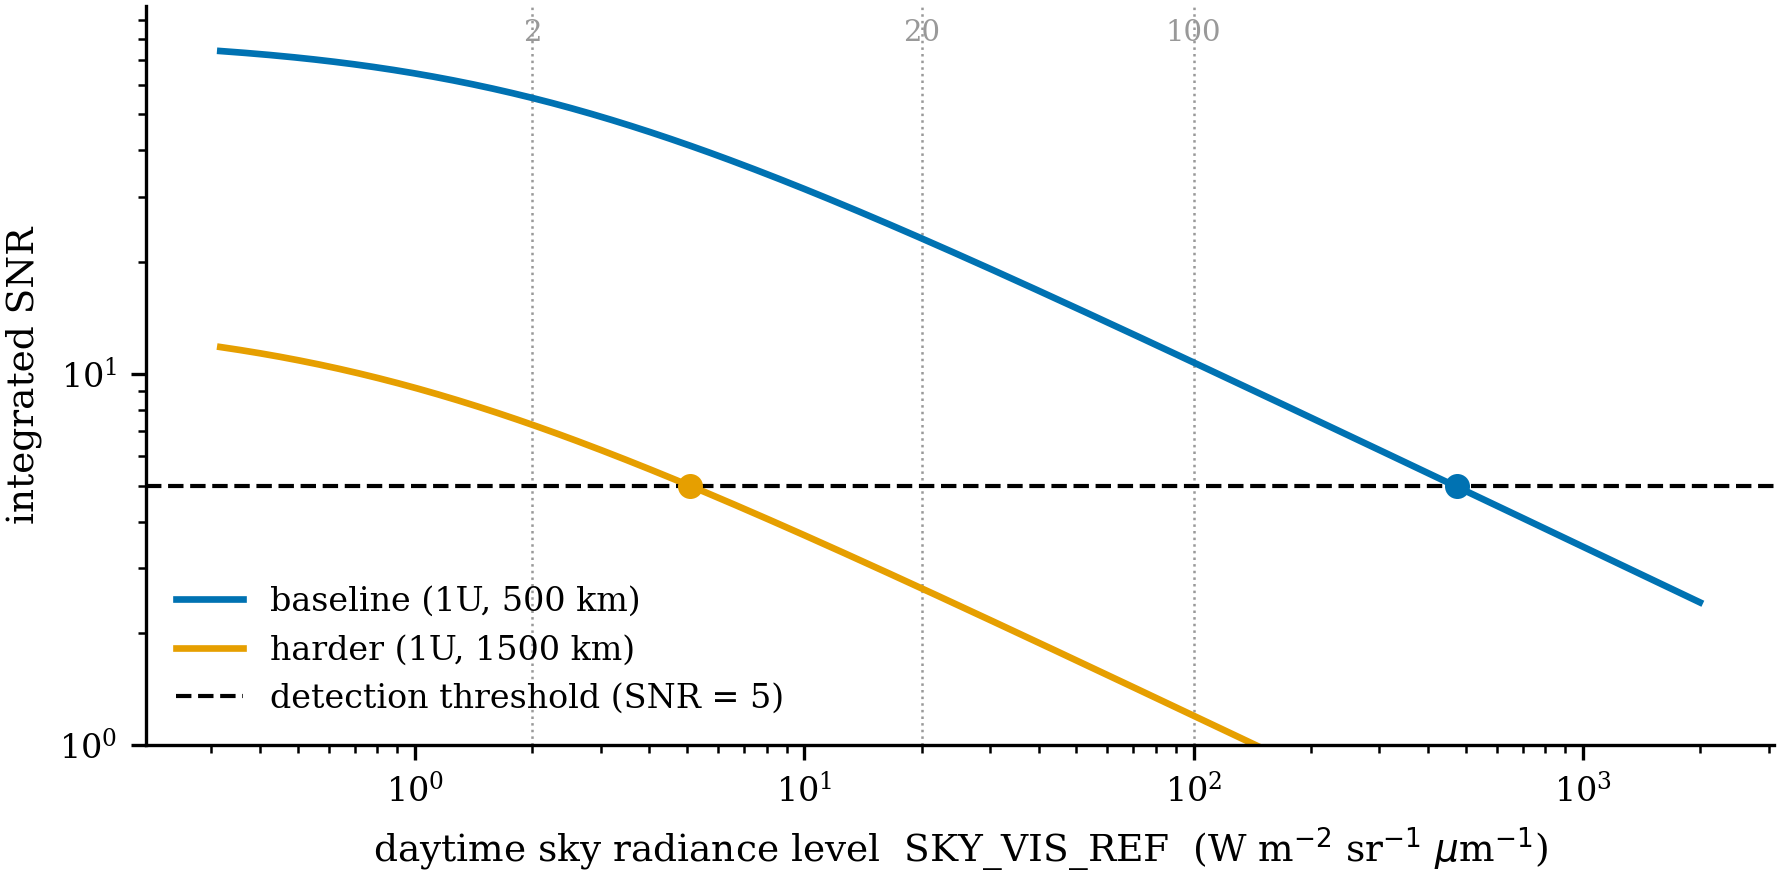

In [20]:
fig, ax = plt.subplots(figsize=(FIGW_DOUBLE, 3.2))
colors = [CB["blue"], CB["orange"]]
for (tname, _), col in zip(TARGETS, colors):
    ax.plot(SKY_AXIS, snr_curves[tname], color=col, label=tname)
ax.axhline(SNR_DETECT, color=CB["black"], ls="--", lw=1.0, label="detection threshold (SNR = %d)" % SNR_DETECT)
for (tname, _), col in zip(TARGETS, colors):
    xc = crossings[tname]
    if np.isfinite(xc):
        ax.plot(xc, SNR_DETECT, "o", color=col, ms=5, zorder=5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylim(1, None)
ymin, ymax = ax.get_ylim()
for sv in SKY_LEVELS:                                   # discrete sky levels used in the tables (numeric, no solar-elevation labels)
    ax.axvline(sv, color=CB["grey"], lw=0.6, ls=":", zorder=0)
    ax.text(sv, ymax*0.92, "%g" % sv, color=CB["grey"], fontsize=7, ha="center", va="top")
ax.set_xlabel(r"daytime sky radiance level  SKY_VIS_REF  (W m$^{-2}$ sr$^{-1}$ $\mu$m$^{-1}$)")
ax.set_ylabel("integrated SNR")
ax.legend(loc="lower left")
save_fig(fig, "fig1_detection_snr_vs_sky", "Primary: SCION-SR integrated SNR vs daytime sky level for baseline and harder LEO targets, with SNR=5 detection threshold and both crossings.", FIGW_DOUBLE)
plt.show()

### Figure 2 — per-wavelength noise budget (representative daytime point)

saved fig2_per_wavelength_budget   (7.0 in wide) -> SCION-SR source-signal and sky spectral electron-rate densities at SKY_VIS_REF=20, with QE(l)*T_atm(l) overlaid.


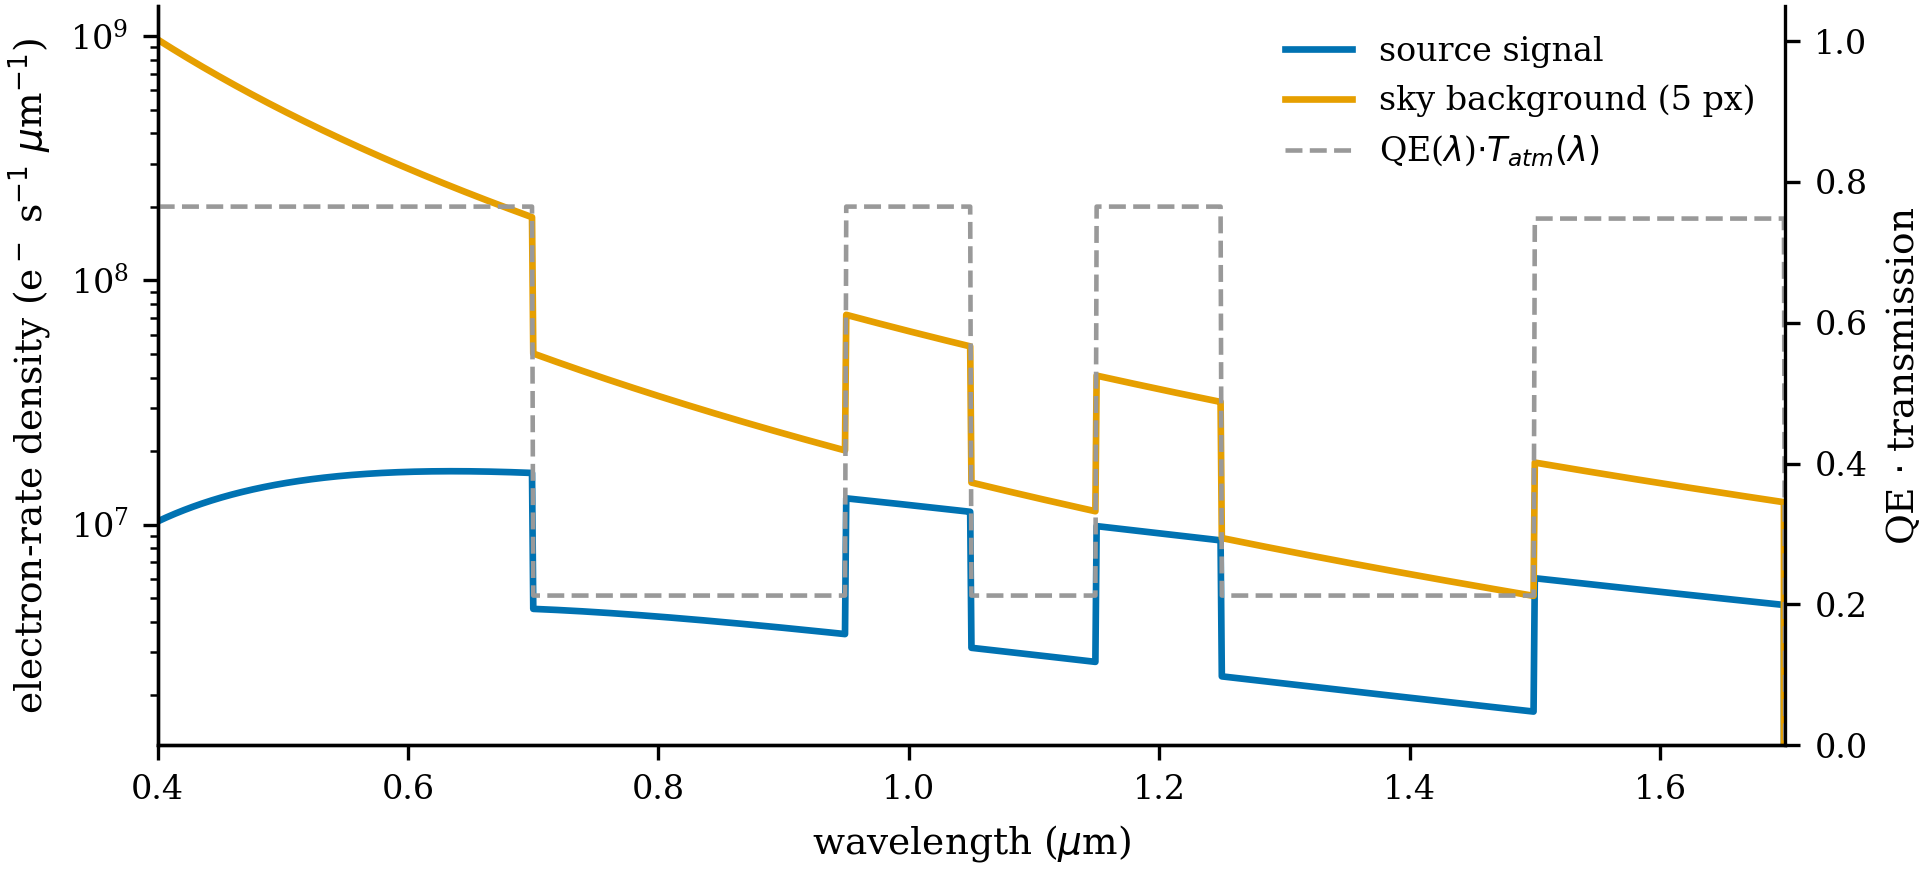

In [21]:
qe_s, _  = qe_of(DET, GRID_UM)
pitch_s  = noise_params(DET)["pitch_um"] or PITCH_TOY_PLACEHOLDER_UM
omega_s  = (pitch_s*1e-6/FOCAL_LENGTH_M)**2
SKY_REP  = 20.0
S_den   = E_tgt_m * A_TEL*TAU_OPTICS*T_atm * lam_m/(H*C) * qe_s * 1e-6                                  # e-/s/um
sky_den = sky_radiance_m(GRID_UM, SKY_REP) * A_TEL*omega_s*TAU_OPTICS*T_atm * lam_m/(H*C) * qe_s * N_PIX_PSF * 1e-6

fig, ax = plt.subplots(figsize=(FIGW_DOUBLE, 3.2))
ax.plot(GRID_UM, S_den,   color=CB["blue"],   label="source signal")
ax.plot(GRID_UM, sky_den, color=CB["orange"], label="sky background (%d px)" % N_PIX_PSF)
ax.set_yscale("log"); ax.set_xlabel(r"wavelength ($\mu$m)")
ax.set_ylabel(r"electron-rate density (e$^-$ s$^{-1}$ $\mu$m$^{-1}$)")
ax.set_xlim(GRID_UM[0], GRID_UM[-1])
ax2 = ax.twinx()
ax2.plot(GRID_UM, qe_s*T_atm, color=CB["grey"], ls="--", lw=1.1, label=r"QE($\lambda$)$\cdot T_{atm}(\lambda)$")
ax2.set_ylabel(r"QE $\cdot$ transmission"); ax2.set_ylim(0, 1.05)
ax2.spines["right"].set_visible(True)
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="upper right")
save_fig(fig, "fig2_per_wavelength_budget", "SCION-SR source-signal and sky spectral electron-rate densities at SKY_VIS_REF=20, with QE(l)*T_atm(l) overlaid.", FIGW_DOUBLE)
plt.show()

### Figure 3 — noise-budget composition across sky level

saved fig3_noise_budget_composition (3.4 in wide) -> SCION-SR baseline noise-budget terms (shot/sky/read/dark) across the three daytime sky levels; sky term grows while others hold.


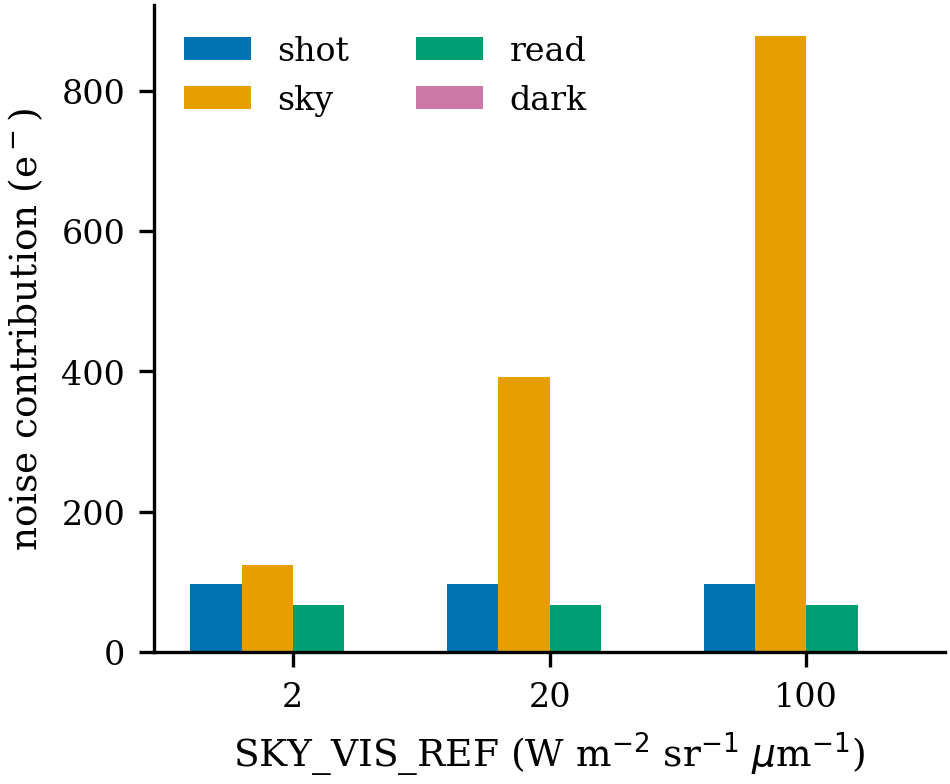

In [22]:
terms_order = ["shot", "sky", "read", "dark"]
term_cols   = {"shot":CB["blue"], "sky":CB["orange"], "read":CB["green"], "dark":CB["purple"]}
vals = {term: [run_detector(DET, sky_vis=sv)["terms"][term] for sv in SKY_LEVELS] for term in terms_order}   # baseline target

fig, ax = plt.subplots(figsize=(FIGW_SINGLE, 2.8))
x = np.arange(len(SKY_LEVELS)); w = 0.2
for i, term in enumerate(terms_order):
    ax.bar(x + (i-1.5)*w, vals[term], w, color=term_cols[term], label=term)
ax.set_xticks(x); ax.set_xticklabels(["%g" % s for s in SKY_LEVELS])
ax.set_xlabel(r"SKY_VIS_REF (W m$^{-2}$ sr$^{-1}$ $\mu$m$^{-1}$)")
ax.set_ylabel(r"noise contribution (e$^-$)")
ax.legend(ncol=2, loc="upper left")
save_fig(fig, "fig3_noise_budget_composition", "SCION-SR baseline noise-budget terms (shot/sky/read/dark) across the three daytime sky levels; sky term grows while others hold.", FIGW_SINGLE)
plt.show()

### Figure 4 — passband sweep (behavioural, atmosphere-limited)

saved fig4_passband_sweep          (3.4 in wide) -> SCION-SR SNR vs longpass cutoff at bright sky (baseline). Behavioural only: the peak is a placeholder-atmosphere artifact, NOT a publishable optimum; >=1.1um operational reference marked.


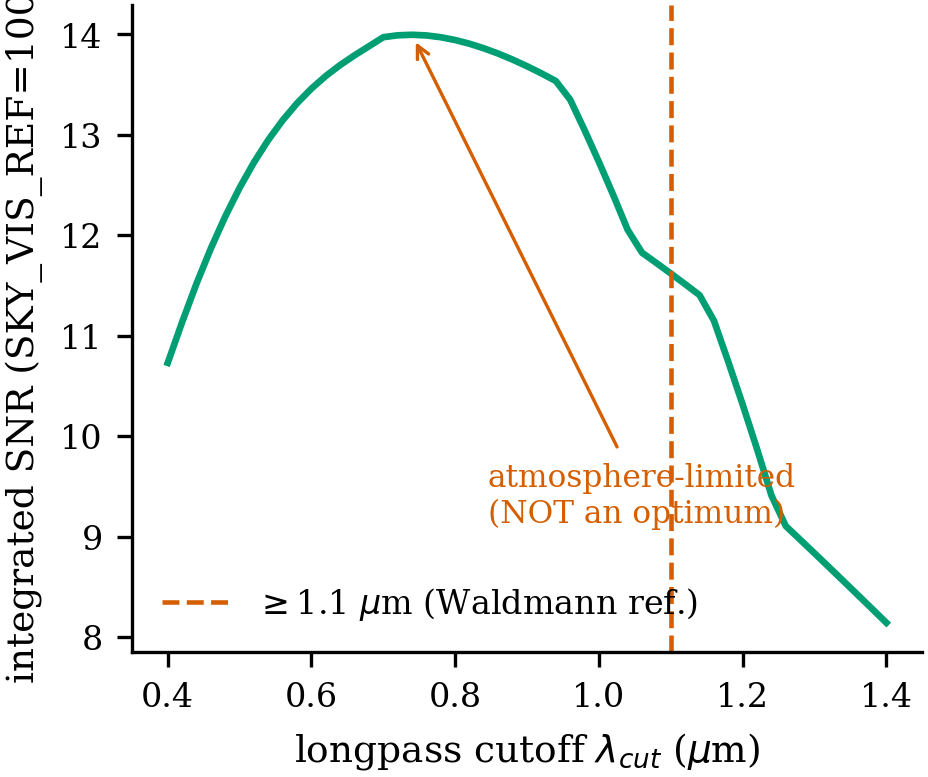

In [23]:
fig, ax = plt.subplots(figsize=(FIGW_SINGLE, 2.8))
ax.plot(CUT_GRID_UM, snr_vs_cut, color=CB["green"])
ax.axvline(LO_CUT_REFERENCE_UM, color=CB["vermilion"], ls="--", lw=1.1,
           label=r"$\geq$1.1 $\mu$m (Waldmann ref.)")
ax.set_xlabel(r"longpass cutoff $\lambda_{cut}$ ($\mu$m)")
ax.set_ylabel(r"integrated SNR (SKY_VIS_REF=%g)" % SWEEP_SKY)
ax.annotate("atmosphere-limited\n(NOT an optimum)", xy=(CUT_GRID_UM[int(np.argmax(snr_vs_cut))], snr_vs_cut.max()),
            xytext=(0.45, 0.2), textcoords="axes fraction", fontsize=7.5, color=CB["vermilion"],
            arrowprops=dict(arrowstyle="->", color=CB["vermilion"], lw=0.8))
ax.legend(loc="lower left")
save_fig(fig, "fig4_passband_sweep", "SCION-SR SNR vs longpass cutoff at bright sky (baseline). Behavioural only: the peak is a placeholder-atmosphere artifact, NOT a publishable optimum; >=1.1um operational reference marked.", FIGW_SINGLE)
plt.show()

### Figure manifest

In [24]:
manifest_path = os.path.join(FIGDIR, "manifest.md")
with open(manifest_path, "w", encoding="utf-8") as f:
    f.write("# Figure manifest - radiometric_detector_comparison.ipynb (SCION-SR daytime custody, AMOS S5)\n\n")
    f.write("Each figure saved as `<stem>.pdf` (vector) and `<stem>.png` (300 dpi).\n\n")
    for stem, desc in FIG_MANIFEST.items():
        f.write("- **%s** - %s\n" % (stem, desc))
print("wrote manifest:", os.path.abspath(manifest_path))
for stem, desc in FIG_MANIFEST.items():
    print("  %-30s %s" % (stem, desc[:70]))

wrote manifest: C:\Users\kevin.kearney\code\SatSim\data\outputs\figures\manifest.md
  fig1_detection_snr_vs_sky      Primary: SCION-SR integrated SNR vs daytime sky level for baseline and
  fig2_per_wavelength_budget     SCION-SR source-signal and sky spectral electron-rate densities at SKY
  fig3_noise_budget_composition  SCION-SR baseline noise-budget terms (shot/sky/read/dark) across the t
  fig4_passband_sweep            SCION-SR SNR vs longpass cutoff at bright sky (baseline). Behavioural 


---
# Daytime-custody utility study (AMOS §6)

*(This section is the paper's §6 **utility study**. It reorients the daytime section from a detection
**demonstration** into a **detector-parameterized utility model**, with the **full well** promoted to a
first-class limiting factor. Prior sections are unchanged and remain regression-gated; this section reuses
the same model functions and the `lo_cut_um` passband. Figures are rich **inline** plots — no file export.)*

The paper claims ground-based daytime/twilight SWIR custody of LEO objects with the **SCION-SR** (VISGaAs)
focal plane. Three physical premises drive this section:

1. **The visible band is doubly disadvantaged for a VISGaAs detector** — the daytime Rayleigh sky is
   brightest there (λ⁻⁴) *and* VISGaAs QE is poor in the visible while good in the NIR–SWIR. The
   intelligent band rejects the visible and keeps the NIR–SWIR.
2. **In bright daytime sky the full well — not the noise floor — caps the exposure.** Sky photoelectrons
   fill every pixel at a fixed rate, so the largest non-saturating exposure is `usable_well / fill_rate`.
   Limiting sensitivity must be evaluated **at that cap**, not at an arbitrary fixed time. This is the
   mechanism by which a **large well converts into deeper daytime reach**, and it is the **headline of
   this section (Fig A).**
3. **Only once the sky is suppressed does the residual limit become the detector noise floor** — read
   noise and dark current. That is a **low-sky / faint-target** regime (Figs B and C): supporting
   physics, *not* the bright-daytime claim.

**No single competing system appears anywhere in this section.** Every claim figure is an **iso-curve
family spanning a representative range of SWIR-detector metrics**, with **only SCION-SR's operating point
marked**. The family *is* the competitor space, so no one system is plotted, labelled, or tabulated.

## §6.1 Parameters (all in one place)

Every knob for this section is grouped here for easy editing. New placeholders are flagged; the detector
electrical specs are read from `configs/detector_configs.json` (config left intact; anonymized only at the
display layer). The swept **families** below define the parameter space the figures span.

In [25]:
import matplotlib as mpl
# --- light READABILITY rcParams for inline viewing (NOT publication export; no savefig anywhere here) ---
mpl.rcParams.update({"figure.dpi": 110, "figure.figsize": (8.4, 4.6), "font.size": 11,
                     "axes.labelsize": 11, "axes.titlesize": 11, "legend.fontsize": 9.5,
                     "axes.grid": True, "grid.alpha": 0.30, "axes.axisbelow": True,
                     # iso-curve families put many lines behind the legend, so re-enable the legend
                     # frame that the publication block above switched off (inline readability only)
                     "legend.frameon": True, "legend.framealpha": 0.90, "legend.edgecolor": "0.8"})
CBB = {"blue":"#0072B2","orange":"#E69F00","green":"#009E73","vermilion":"#D55E00",
       "sky":"#56B4E9","purple":"#CC79A7","black":"#000000","grey":"#8C8C8C"}

# ---- reference scenario knobs (PLACEHOLDERS unless noted) ----
REF_SKY_DAYTIME   = 20.0     # W/m^2/sr/um visible zenith, reference daytime sky   [PLACEHOLDER, matches prior section]
T_REF_S           = 0.010    # short reference exposure, 10 ms                     [PLACEHOLDER]; SNR ~ sqrt(t) in sky/dark-limited regimes
T_MAX_REQUEST_S   = 1.0      # longest exposure a tasker would REQUEST             [PLACEHOLDER]; the well may cap it below this
T_LONG_S          = 1.0      # long (dark-limited) exposure for the low-sky panels [PLACEHOLDER]
SKY_SUPPRESSED    = 0.0      # band + observing strategy have fully suppressed the sky -> detector-limited
RANGE_REF_KM      = 1000.0   # reference slant range for limiting size             [PLACEHOLDER]; flux ~ 1/range^2
OPERATIONAL_BAND_UM = 1.1    # intelligent NIR-SWIR band = Waldmann >=1.1 um longpass (operational reference)
BASELINE_RANGE_KM = SCEN["range_km"]   # 500 km, where E_tgt_m (baseline) is defined
BASELINE_SIZE_M   = 0.10     # 1U characteristic size for the baseline target
# SNR_DETECT (=5) is reused from the daytime-custody section above.
MAG_BASE = -26.74 - 2.5*np.log10(np.trapz(E_tgt_m, lam_m)/SOLAR_CONSTANT)   # baseline broadband apparent mag

# ---- SWEPT FAMILIES: these span the SWIR-detector parameter space (i.e. the competitor space).
# ---- No single competing system is represented, named, marked, or tabulated anywhere in this section.
WELL_FAMILY_E   = [1e4, 1e5, 1e6, 1e7]               # per-pixel full well, decade family
READ_FAMILY_E   = [5.0, 10.0, 20.0, 50.0, 100.0]     # read noise, e- RMS
DARK_FAMILY_E_S = [1.0, 10.0, 100.0, 1000.0, 5000.0] # dark current, e-/px/s
SKY_FAMILY      = SKY_LEVELS                         # [2, 20, 100] reused from the daytime section above
T_AXIS_S        = np.logspace(-3, 1, 240)            # REQUESTED integration time, 1 ms .. 10 s
WELL_USABLE_FRACTION = 1.0   # [IDEALIZATION] the entire well is treated as usable: no anti-blooming
                             # headroom and no linearity derating. A real ROIC would use ~70-90%.

# ---- realistic wavelength-resolved QE placeholder ----
# NAMED PLACEHOLDER pending the measured datasheet curve. Anchor (um, QE) points -> linear interp.
# VISGaAs (SCION-SR): poor in the visible, rising through the NIR, peak ~0.85 across ~1.0-1.5 um, roll off to 1.7.
QE_VISGAAS_ANCHORS = [(0.40,0.03),(0.50,0.04),(0.60,0.05),(0.70,0.08),(0.80,0.20),(0.90,0.45),
                      (1.00,0.70),(1.10,0.85),(1.20,0.85),(1.30,0.85),(1.40,0.83),(1.50,0.80),(1.60,0.65),(1.70,0.45)]
def _qe_from_anchors(anchors):
    a = np.array(anchors); return np.interp(GRID_UM, a[:,0], a[:,1])
QE_VISGAAS = _qe_from_anchors(QE_VISGAAS_ANCHORS)   # QE_VISGAAS_PARAMETRIC placeholder

# ---- the one marked operating point (electrical specs from config; label anonymized) ----
SCION = dict(label="SCION-SR", qe=QE_VISGAAS,
             read_e   =CFG["scion_visgaas"]["read_noise"]["value"],     # < 30 e-  (UPPER BOUND)
             dark_e_s =CFG["scion_visgaas"]["dark_current"]["value"],   # < 15 e-/px/s (UPPER BOUND); deep-cooled -70/-75 C
             full_well=CFG["scion_visgaas"]["full_well_e"],             # 1 M e- per pixel
             pitch_um =CFG["scion_visgaas"]["pixel_pitch_um"], bounds=True)

# ---- NIR-SWIR color sub-bands (inside the VISGaAs good-QE region) ----
COLOR_NIR_UM  = (1.00, 1.20)
COLOR_SWIR_UM = (1.40, 1.70)

print("baseline broadband mag = %.2f | operational band >= %.2f um | t_ref = %g ms | range_ref = %g km"
      % (MAG_BASE, OPERATIONAL_BAND_UM, T_REF_S*1e3, RANGE_REF_KM))
print("marked operating point -- %s: read %g e- (bound), dark %g e-/px/s (bound, deep-cooled), full well %.0e e-"
      % (SCION["label"], SCION["read_e"], SCION["dark_e_s"], SCION["full_well"]))
print("swept families: well %s e- | read %s e- | dark %s e-/px/s | sky %s W/m^2/sr/um"
      % (["%.0e" % w for w in WELL_FAMILY_E], READ_FAMILY_E, DARK_FAMILY_E_S, list(SKY_FAMILY)))

baseline broadband mag = 8.34 | operational band >= 1.10 um | t_ref = 10 ms | range_ref = 1000 km
marked operating point -- SCION-SR: read 30 e- (bound), dark 15 e-/px/s (bound, deep-cooled), full well 1e+06 e-
swept families: well ['1e+04', '1e+05', '1e+06', '1e+07'] e- | read [5.0, 10.0, 20.0, 50.0, 100.0] e- | dark [1.0, 10.0, 100.0, 1000.0, 5000.0] e-/px/s | sky [2.0, 20.0, 100.0] W/m^2/sr/um


## §6.2 Realistic QE(λ) (replaces flat-at-peak for this section)

The flat-at-peak QE used in the benchmark above cannot support a band-selection argument. Here QE(λ) is
**wavelength-resolved**, reproducing the datasheet's qualitative shape.

> ## ⚠️ Named parametric placeholder — pending the measured curve
> No digitized datasheet QE exists in the repo (`qe_curve` is null for every detector), so
> `QE_VISGAAS_PARAMETRIC` is a **hand-built parametric placeholder** matching the qualitative shape only.
> **The band-selection and color results below depend on this QE shape**, so the *direction* (reject the
> visible, keep the NIR–SWIR) is robust, but the **quantitative optimum is pending the measured curve.**
> This remains the key pending input for §6.

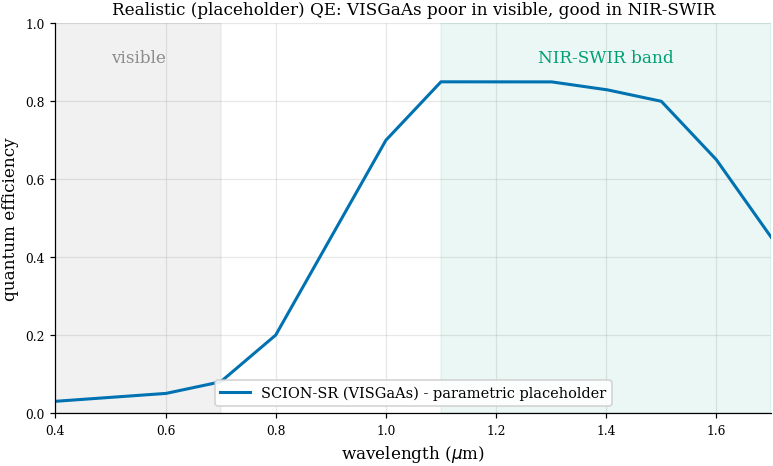

In [26]:
fig, ax = plt.subplots()
ax.plot(GRID_UM, QE_VISGAAS, color=CBB["blue"], lw=2, label="SCION-SR (VISGaAs) - parametric placeholder")
ax.axvspan(0.4, 0.7, color=CBB["grey"], alpha=0.12); ax.text(0.55, 0.9, "visible", ha="center", color=CBB["grey"])
ax.axvspan(OPERATIONAL_BAND_UM, 1.7, color=CBB["green"], alpha=0.08)
ax.text(1.4, 0.9, "NIR-SWIR band", ha="center", color=CBB["green"])
ax.set_xlabel(r"wavelength ($\mu$m)"); ax.set_ylabel("quantum efficiency")
ax.set_xlim(0.4, 1.7); ax.set_ylim(0, 1.0); ax.legend(loc="lower center")
ax.set_title("Realistic (placeholder) QE: VISGaAs poor in visible, good in NIR-SWIR")
plt.show()

## §6.3 Limiting sensitivity — definition and solver

**Limiting sensitivity** = the faintest target detectable at `SNR_DETECT` for a given exposure, reported as
**limiting apparent magnitude** and **smallest detectable characteristic size** at a reference slant range.
We invert the SNR relation for the target signal (the sky/dark/read terms are target-independent), which
reduces to a quadratic root. Scalings are noted explicitly: SNR ∝ √t in the sky/dark-limited regime, and
flux ∝ 1/range² so limiting size ∝ range.

In [27]:
def _signal_rate(qe, lo, E=None):
    E = E_tgt_m if E is None else E
    return np.trapz(E * A_TEL * TAU_OPTICS * T_atm * lam_m/(H*C) * qe * _passband_mask(lo), lam_m)
def _sky_rate_pix(qe, lo, sky_vis, pitch_um):
    om = (pitch_um*1e-6/FOCAL_LENGTH_M)**2
    return np.trapz(sky_radiance_m(GRID_UM, sky_vis) * A_TEL * om * TAU_OPTICS * T_atm * lam_m/(H*C) * qe * _passband_mask(lo), lam_m)
def _fixed_noise_var(qe, lo, sky_vis, t, read_e, dark_e_s, pitch_um):
    return dark_e_s*t*N_PIX_PSF + _sky_rate_pix(qe, lo, sky_vis, pitch_um)*t*N_PIX_PSF + read_e**2*N_PIX_PSF
def _limiting_signal_e(N0sq):
    """Solve S_e/sqrt(S_e + N0^2) = SNR_DETECT for the limiting signal electrons (root of a quadratic)."""
    D = SNR_DETECT**2
    return (D + np.sqrt(D**2 + 4*D*N0sq)) / 2.0
def limiting_mag(qe, lo, sky_vis, t, read_e, dark_e_s, pitch_um):
    Se_base = _signal_rate(qe, lo) * t                                    # baseline target signal at this band/exposure
    Se_lim  = _limiting_signal_e(_fixed_noise_var(qe, lo, sky_vis, t, read_e, dark_e_s, pitch_um))
    return MAG_BASE + 2.5*np.log10(Se_base / Se_lim)                      # fainter target -> larger magnitude
def limiting_size_m(qe, lo, sky_vis, t, read_e, dark_e_s, pitch_um, range_km):
    Se_base = _signal_rate(qe, lo) * t * (BASELINE_RANGE_KM/range_km)**2  # flux ~ 1/range^2
    Se_lim  = _limiting_signal_e(_fixed_noise_var(qe, lo, sky_vis, t, read_e, dark_e_s, pitch_um))
    return BASELINE_SIZE_M * np.sqrt(Se_lim / Se_base)                    # flux ~ size^2

def _scion_limmag(lo, sky_vis, t, read_e=None, dark_e_s=None):
    """limiting_mag at the marked operating point, with one metric optionally overridden for a sweep."""
    return limiting_mag(SCION["qe"], lo, sky_vis, t,
                        SCION["read_e"] if read_e is None else read_e,
                        SCION["dark_e_s"] if dark_e_s is None else dark_e_s, SCION["pitch_um"])

lo = OPERATIONAL_BAND_UM
_m = _scion_limmag(lo, REF_SKY_DAYTIME, T_REF_S)
_s = limiting_size_m(SCION["qe"], lo, REF_SKY_DAYTIME, T_REF_S, SCION["read_e"], SCION["dark_e_s"], SCION["pitch_um"], RANGE_REF_KM)
print("At the intelligent band >=%.1f um, sky=%g, t=%g ms (uncapped reference exposure):" % (lo, REF_SKY_DAYTIME, T_REF_S*1e3))
print("  %-10s limiting mag %.2f  |  smallest size @ %g km = %.3f m" % (SCION["label"], _m, RANGE_REF_KM, _s))
print("scalings: SNR ~ sqrt(t) (sky/dark-limited)  ->  limiting flux ~ 1/sqrt(t);   flux ~ 1/range^2  ->  limiting size ~ range")

At the intelligent band >=1.1 um, sky=20, t=10 ms (uncapped reference exposure):
  SCION-SR   limiting mag 11.35  |  smallest size @ 1000 km = 0.050 m
scalings: SNR ~ sqrt(t) (sky/dark-limited)  ->  limiting flux ~ 1/sqrt(t);   flux ~ 1/range^2  ->  limiting size ~ range


## §6.4 Intelligent NIR–SWIR band selection — **Fig D**

Sweep the **lower cutoff** `lo_cut_um` (upper edge fixed at the 1.7 µm detector cutoff) with the realistic
QE, one **iso-curve per daytime sky level**, at the short reference exposure. The metric is limiting
sensitivity. QE(λ) and the sky spectral density are overlaid so the trade is visible: sky rejected below
the cutoff vs. signal retained above it. *(Figure letters follow the paper's figure list, not notebook
order — Fig D comes first here because the band choice feeds every later figure.)*

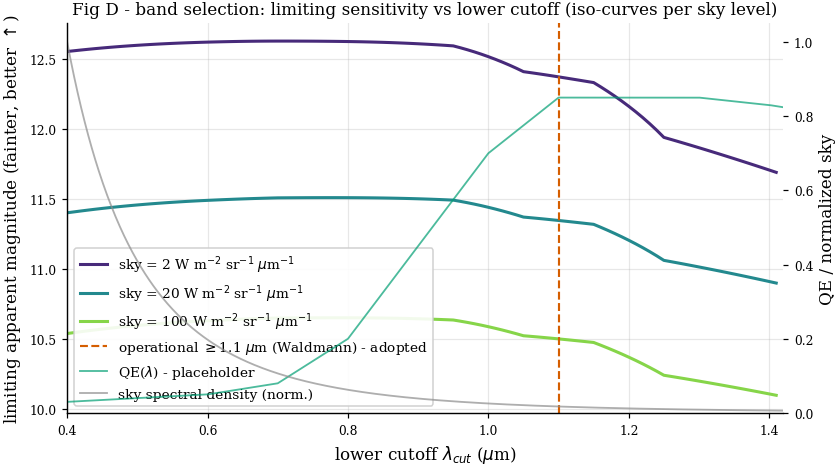

model optimum lower cutoff per sky level (DIRECTION ONLY - atmosphere-limited, see below):
  sky=   2.0 -> optimum 0.70 um  (limiting mag 12.63 there vs 12.37 at the operational 1.1 um)
  sky=  20.0 -> optimum 0.78 um  (limiting mag 11.51 there vs 11.35 at the operational 1.1 um)
  sky= 100.0 -> optimum 0.78 um  (limiting mag 10.65 there vs 10.50 at the operational 1.1 um)


In [28]:
cuts = np.arange(0.40, 1.42, 0.01)
fam_cols = plt.cm.viridis(np.linspace(0.12, 0.82, len(SKY_FAMILY)))

fig, ax = plt.subplots()
lm_by_sky = {}
for sv, col in zip(SKY_FAMILY, fam_cols):
    lm = np.array([_scion_limmag(c, sv, T_REF_S) for c in cuts])
    lm_by_sky[sv] = lm
    ax.plot(cuts, lm, color=col, lw=2, label=r"sky = %g W m$^{-2}$ sr$^{-1}$ $\mu$m$^{-1}$" % sv)
ax.axvline(OPERATIONAL_BAND_UM, color=CBB["vermilion"], ls="--", lw=1.4,
           label=r"operational $\geq$1.1 $\mu$m (Waldmann) - adopted")
ax.set_xlabel(r"lower cutoff $\lambda_{cut}$ ($\mu$m)")
ax.set_ylabel("limiting apparent magnitude (fainter, better $\\uparrow$)")
ax.set_title("Fig D - band selection: limiting sensitivity vs lower cutoff (iso-curves per sky level)")
ax2 = ax.twinx()
ax2.plot(GRID_UM, QE_VISGAAS, color=CBB["green"], lw=1.2, alpha=0.7, label=r"QE($\lambda$) - placeholder")
sky_den = sky_radiance_m(GRID_UM, REF_SKY_DAYTIME); sky_den = sky_den/sky_den.max()
ax2.plot(GRID_UM, sky_den, color=CBB["grey"], lw=1.2, alpha=0.7, label="sky spectral density (norm.)")
ax2.set_ylabel("QE / normalized sky"); ax2.set_ylim(0, 1.05); ax2.grid(False)
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="lower left", fontsize=9); ax.set_xlim(0.4, 1.42)
plt.show()

print("model optimum lower cutoff per sky level (DIRECTION ONLY - atmosphere-limited, see below):")
for sv in SKY_FAMILY:
    lm = lm_by_sky[sv]
    print("  sky=%6.1f -> optimum %.2f um  (limiting mag %.2f there vs %.2f at the operational %.1f um)"
          % (sv, cuts[int(np.argmax(lm))], lm.max(), _scion_limmag(OPERATIONAL_BAND_UM, sv, T_REF_S), OPERATIONAL_BAND_UM))

**Finding (method + direction, pending the measured QE).** The realistic QE confirms the **robust
direction**: reject the visible, keep the NIR–SWIR. The model's optimal *lower cutoff* sits near the
visible/NIR boundary — the biggest payoff is discarding the low-QE, λ⁻⁴-bright **visible**, after which the
high-QE NIR–SWIR is worth keeping. The model optimum is **bluer** than Waldmann's operational **≥1.1 µm**
longpass because this section's placeholder atmosphere is a pure λ⁻⁴ Rayleigh sky with **no
water-absorption or thermal structure** (deferred, per hard stops) — there is no penalty to keeping
0.8–1.1 µm here, whereas the operational ≥1.1 µm cutoff reflects that omitted physics. We therefore
**adopt ≥1.1 µm (Waldmann) as the intelligent band** for every figure below, and treat the exact model
optimum as placeholder-QE/atmosphere dependent — **a direction, not a publishable number.**

## §6.5 The full-well / saturation cap — **the daytime headline**

Every pixel accumulates **sky + dark + the target's own signal** over the integration. When the accumulated
charge reaches the usable well the pixel saturates, so the well sets the **longest usable exposure**:

$$t_{sat} = \frac{f_{usable}\,W_{full}}{\dot{n}_{sky} + \dot{n}_{dark} + \dot{n}_{signal}/N_{pix}}$$

On a bright daytime sky the sky term dominates that denominator by orders of magnitude, so
$t_{sat} \propto W_{full}$. Limiting sensitivity must therefore be evaluated at
**t = min(t_requested, t_sat)** — the largest *non-saturating* exposure — which is exactly how **well depth
converts into daytime reach**. The `run_detector` budget in the benchmark section above is untouched
(regression-gated); this is a new, additive layer on top of the §6.3 solver.

> **Idealization, flagged:** `WELL_USABLE_FRACTION = 1.0` treats the *entire* well as usable — no
> anti-blooming headroom, no linearity derating (a real ROIC would use ~70–90 %). The signal term also
> assumes the PSF spreads charge **evenly** over `N_PIX_PSF`; a real peaked PSF fills its central pixel
> faster, so the caps below are **optimistic** on the signal term. Neither is given an invented number.

In [29]:
def well_fill_rate(qe, lo, sky_vis, dark_e_s, pitch_um, S_rate=0.0):
    """Per-pixel accumulation rate [e-/px/s] = sky + dark + source signal spread over the PSF footprint.
    S_rate=0.0 (default) is the BACKGROUND fill rate -- the sky+dark rate that caps the exposure for a
    faint (limiting) target, whose own contribution to the well is negligible."""
    return _sky_rate_pix(qe, lo, sky_vis, pitch_um) + dark_e_s + S_rate/N_PIX_PSF

def accumulated_e(t, qe, lo, sky_vis, dark_e_s, pitch_um, S_rate=0.0):
    """Accumulated per-pixel charge [e-] after an exposure t."""
    return well_fill_rate(qe, lo, sky_vis, dark_e_s, pitch_um, S_rate) * t

def is_saturated(t, full_well, qe, lo, sky_vis, dark_e_s, pitch_um, S_rate=0.0):
    """True when the accumulated charge exceeds the usable well."""
    return accumulated_e(t, qe, lo, sky_vis, dark_e_s, pitch_um, S_rate) > WELL_USABLE_FRACTION*full_well

def t_saturate(full_well, qe, lo, sky_vis, dark_e_s, pitch_um, S_rate=0.0):
    """Largest NON-SATURATING exposure [s] = usable well / per-pixel fill rate."""
    return WELL_USABLE_FRACTION*full_well / well_fill_rate(qe, lo, sky_vis, dark_e_s, pitch_um, S_rate)

def limiting_mag_capped(lo, sky_vis, t_request, full_well, read_e=None, dark_e_s=None):
    """Limiting magnitude at the largest non-saturating exposure <= t_request.
    Returns (limiting_mag, t_used, capped_flag). read_e/dark_e_s default to the marked operating point."""
    r  = SCION["read_e"]   if read_e   is None else read_e
    dk = SCION["dark_e_s"] if dark_e_s is None else dark_e_s
    t_s = t_saturate(full_well, SCION["qe"], lo, sky_vis, dk, SCION["pitch_um"])
    t_u = min(t_request, t_s)
    return limiting_mag(SCION["qe"], lo, sky_vis, t_u, r, dk, SCION["pitch_um"]), t_u, bool(t_request > t_s)

# ---- fill-rate breakdown on the reference daytime sky ----
lo      = OPERATIONAL_BAND_UM
b_pix   = _sky_rate_pix(QE_VISGAAS, lo, REF_SKY_DAYTIME, SCION["pitch_um"])
S_base  = _signal_rate(QE_VISGAAS, lo)
fill_bg = well_fill_rate(QE_VISGAAS, lo, REF_SKY_DAYTIME, SCION["dark_e_s"], SCION["pitch_um"])
fill_tg = well_fill_rate(QE_VISGAAS, lo, REF_SKY_DAYTIME, SCION["dark_e_s"], SCION["pitch_um"], S_rate=S_base)
print("Per-pixel fill rate, band >=%.1f um, reference daytime sky = %g W/m^2/sr/um:" % (lo, REF_SKY_DAYTIME))
print("  sky %.3e  +  dark %.3e  =  background %.3e e-/px/s" % (b_pix, SCION["dark_e_s"], fill_bg))
print("  (the bright baseline 1U target itself adds %.3e e-/px/s -> %.3e total; a LIMITING target adds ~0)"
      % (S_base/N_PIX_PSF, fill_tg))

# ---- the well -> integration-cap -> limiting-sensitivity result ----
rows = []
for fw in WELL_FAMILY_E:
    ts   = t_saturate(fw, QE_VISGAAS, lo, REF_SKY_DAYTIME, SCION["dark_e_s"], SCION["pitch_um"])
    ts_t = t_saturate(fw, QE_VISGAAS, lo, REF_SKY_DAYTIME, SCION["dark_e_s"], SCION["pitch_um"], S_rate=S_base)
    m    = _scion_limmag(lo, REF_SKY_DAYTIME, ts)
    sz   = limiting_size_m(QE_VISGAAS, lo, REF_SKY_DAYTIME, ts, SCION["read_e"], SCION["dark_e_s"], SCION["pitch_um"], RANGE_REF_KM)
    rows.append({"full well [e-]": "%.0e" % fw,
                 "t_sat (background) [s]": "%.4g" % ts,
                 "t_sat (w/ 1U target) [s]": "%.4g" % ts_t,
                 "limiting mag @ t_sat": "%.2f" % m,
                 "limiting size @ %g km [m]" % RANGE_REF_KM: "%.3f" % sz,
                 "marked": "<-- SCION-SR" if np.isclose(fw, SCION["full_well"]) else ""})
sat_tbl = pd.DataFrame(rows).set_index("full well [e-]")
print("\nSaturation cap vs well depth on the reference daytime sky (band >=%.1f um, SNR_DETECT=%d):" % (lo, SNR_DETECT))
print(sat_tbl.to_string())

# ---- sky-shot-dominance check AT the cap (this is what validates the 1.25*log10(t) scaling) ----
ts_scion = t_saturate(SCION["full_well"], QE_VISGAAS, lo, REF_SKY_DAYTIME, SCION["dark_e_s"], SCION["pitch_um"])
S_lim    = _limiting_signal_e(_fixed_noise_var(QE_VISGAAS, lo, REF_SKY_DAYTIME, ts_scion,
                                              SCION["read_e"], SCION["dark_e_s"], SCION["pitch_um"]))
var = {"sky shot":                     b_pix*ts_scion*N_PIX_PSF,
       "dark shot":                    SCION["dark_e_s"]*ts_scion*N_PIX_PSF,
       "read":                         SCION["read_e"]**2*N_PIX_PSF,
       "source shot (limiting target)": S_lim}
tot = sum(var.values())
print("\nNoise budget AT the saturation cap (t_sat = %.4g s, %s well %.0e e-):" % (ts_scion, SCION["label"], SCION["full_well"]))
for k, v in var.items():
    print("   %-31s variance %10.3e  = %7.3f%% of total" % (k, v, 100*v/tot))
dom     = max(var, key=var.get)
rd_frac = 100*(var["read"] + var["dark shot"])/tot
print("   => DOMINANT: %s (%.2f%%).  read + dark = %.4f%% of the variance -> NEGLIGIBLE." % (dom, 100*var[dom]/tot, rd_frac))
print("   CHECK %s: the cap is reached in the SKY-SHOT-DOMINATED regime."
      % ("PASSED" if dom == "sky shot" and rd_frac < 1.0 else "FAILED"))
print("   There N0^2 ~ t and S_base ~ t, so limiting mag = const + 1.25*log10(t), and t_sat ~ W_full:")
print("   ->  +1.25 mag of limiting sensitivity per DECADE of well depth (limiting size x %.2f per decade)." % 10**-0.25)

# ---- Fig D used a fixed short exposure; confirm it never saturates anywhere in that sweep ----
_tsat_min = min(t_saturate(SCION["full_well"], QE_VISGAAS, c, sv, SCION["dark_e_s"], SCION["pitch_um"])
                for c in np.arange(0.40, 1.42, 0.02) for sv in SKY_FAMILY)
print("\ncheck: Fig D's fixed t = %g ms sits below the %s saturation cap everywhere in that sweep (smallest cap %.4g s)."
      % (T_REF_S*1e3, SCION["label"], _tsat_min))

Per-pixel fill rate, band >=1.1 um, reference daytime sky = 20 W/m^2/sr/um:
  sky 1.628e+06  +  dark 1.500e+01  =  background 1.628e+06 e-/px/s
  (the bright baseline 1U target itself adds 4.743e+05 e-/px/s -> 2.102e+06 total; a LIMITING target adds ~0)

Saturation cap vs well depth on the reference daytime sky (band >=1.1 um, SNR_DETECT=5):
               t_sat (background) [s] t_sat (w/ 1U target) [s] limiting mag @ t_sat limiting size @ 1000 km [m]        marked
full well [e-]                                                                                                               
1e+04                        0.006144                 0.004757                11.06                       0.057              
1e+05                         0.06144                  0.04757                12.36                       0.031              
1e+06                          0.6144                   0.4757                13.62                       0.018  <-- SCION-SR
1e+07                     

### Fig A — limiting sensitivity vs integration time, one iso-curve per full well *(headline)*

x is the **requested** integration time; y is the limiting sensitivity **actually achieved**, i.e. evaluated
at `min(t_requested, t_sat)`. Each well therefore follows the common √t improvement until *its own*
saturation knee, then **plateaus** — asking for more exposure buys nothing once the well is full. The
knees are marked; **only SCION-SR's well is identified.** This is the daytime-custody figure: larger well →
longer non-saturating integration → deeper limiting sensitivity.

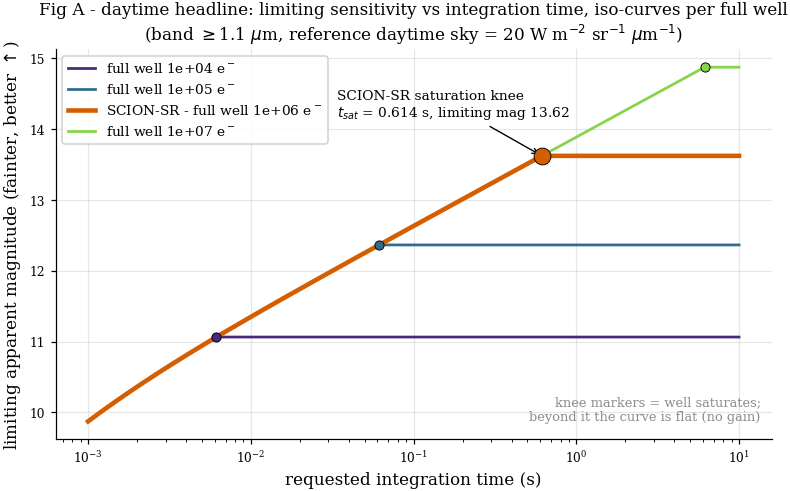

Across the swept well family (1e+04 -> 1e+07 e-, 3 decades) the achievable limiting magnitude on the
reference daytime sky improves 11.06 -> 14.87 mag (+3.81 mag, i.e. +1.27 mag per decade of well).
SCION-SR sits at 1e+06 e-, with a 0.614 s non-saturating exposure and limiting mag 13.62 at the reference sky.


In [30]:
fam_cols = plt.cm.viridis(np.linspace(0.12, 0.82, len(WELL_FAMILY_E)))
fig, ax = plt.subplots()
for fw, col in zip(WELL_FAMILY_E, fam_cols):
    marked = bool(np.isclose(fw, SCION["full_well"]))
    lm = np.array([limiting_mag_capped(OPERATIONAL_BAND_UM, REF_SKY_DAYTIME, t, fw)[0] for t in T_AXIS_S])
    ax.plot(T_AXIS_S, lm, color=(CBB["vermilion"] if marked else col), lw=(3.0 if marked else 1.8),
            zorder=(5 if marked else 3),
            label=(r"%s - full well %.0e e$^-$" % (SCION["label"], fw)) if marked else (r"full well %.0e e$^-$" % fw))
    ts = t_saturate(fw, QE_VISGAAS, OPERATIONAL_BAND_UM, REF_SKY_DAYTIME, SCION["dark_e_s"], SCION["pitch_um"])
    ax.plot(ts, _scion_limmag(OPERATIONAL_BAND_UM, REF_SKY_DAYTIME, ts), "o",
            color=(CBB["vermilion"] if marked else col), ms=(11 if marked else 6),
            mec=CBB["black"], mew=0.6, zorder=6)

m_knee = _scion_limmag(OPERATIONAL_BAND_UM, REF_SKY_DAYTIME, ts_scion)
ax.annotate("%s saturation knee\n$t_{sat}$ = %.3g s, limiting mag %.2f" % (SCION["label"], ts_scion, m_knee),
            xy=(ts_scion, m_knee), xytext=(ts_scion*0.055, m_knee+0.55), fontsize=9,
            arrowprops=dict(arrowstyle="->", color=CBB["black"], lw=0.9))
ax.text(0.985, 0.04, "knee markers = well saturates;\nbeyond it the curve is flat (no gain)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color=CBB["grey"])
ax.set_xscale("log")
ax.set_xlabel("requested integration time (s)")
ax.set_ylabel("limiting apparent magnitude (fainter, better $\\uparrow$)")
ax.set_title("Fig A - daytime headline: limiting sensitivity vs integration time, iso-curves per full well\n"
             r"(band $\geq$1.1 $\mu$m, reference daytime sky = %g W m$^{-2}$ sr$^{-1}$ $\mu$m$^{-1}$)" % REF_SKY_DAYTIME)
ax.legend(loc="upper left", fontsize=9)
plt.show()

_lo_w, _hi_w = WELL_FAMILY_E[0], WELL_FAMILY_E[-1]
_m_lo = limiting_mag_capped(OPERATIONAL_BAND_UM, REF_SKY_DAYTIME, T_AXIS_S[-1], _lo_w)[0]
_m_hi = limiting_mag_capped(OPERATIONAL_BAND_UM, REF_SKY_DAYTIME, T_AXIS_S[-1], _hi_w)[0]
print("Across the swept well family (%.0e -> %.0e e-, %d decades) the achievable limiting magnitude on the"
      % (_lo_w, _hi_w, round(np.log10(_hi_w/_lo_w))))
print("reference daytime sky improves %.2f -> %.2f mag (%+.2f mag, i.e. %+.2f mag per decade of well)."
      % (_m_lo, _m_hi, _m_hi-_m_lo, (_m_hi-_m_lo)/np.log10(_hi_w/_lo_w)))
print("%s sits at %.0e e-, with a %.3g s non-saturating exposure and limiting mag %.2f at the reference sky."
      % (SCION["label"], SCION["full_well"], ts_scion, m_knee))

**Headline finding (Fig A).** On the reference daytime sky the well — not the noise floor — sets the
usable exposure, and the saturation cap scales linearly with well depth. Because the cap is reached in the
**sky-shot-dominated** regime (verified numerically in §6.5: read + dark are a *fraction of a percent* of
the variance there), limiting magnitude improves as `1.25·log₁₀ t`, so **each decade of well depth buys
≈ 1.25 mag** of daytime limiting sensitivity — equivalently the smallest detectable size shrinks by ≈ 0.56×
per decade. SCION-SR's **1 M e⁻** well is the mechanism that converts into deeper daytime reach; the sky
levels remain placeholders, so the *scaling* is the result, not the absolute magnitudes.

### Fig B — **low-sky / faint-target regime:** limiting sensitivity vs dark current, iso-curves per read noise

> **Regime label — read this before quoting the figure.** Fig B is evaluated with the **sky fully
> suppressed** and a **long (1 s) integration**: the low-sky, faint-target floor. It is **not** a
> bright-daytime result and must not be read as one — in this regime the well is nowhere near limiting
> (confirmed in the printed check below). The bright-daytime claim is **Fig A**. Fig B answers a
> different, supporting question: once the sky is gone, which detector metric sets the floor?

At long integration the floor is **dark current**, and the iso-curves show how much read noise still
matters. Only SCION-SR's operating point is marked.

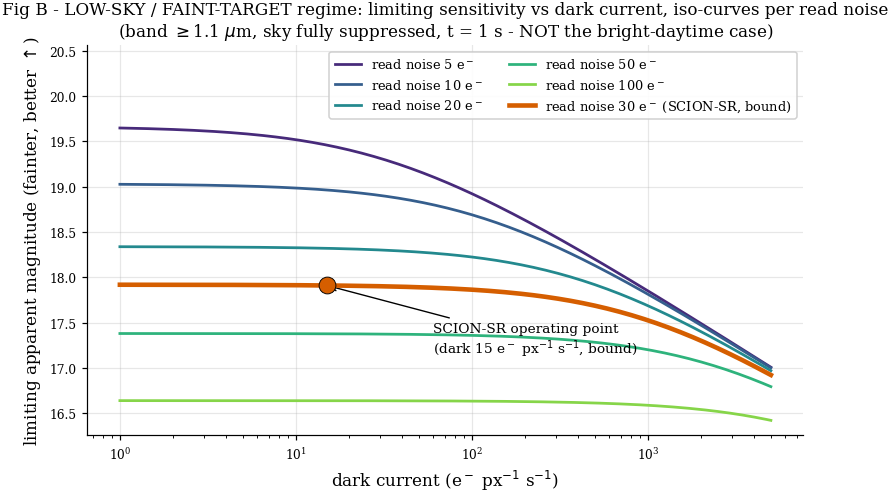

Regime check: with the sky suppressed the well is NOT limiting here -- the smallest saturation cap in
  this panel is 200 s, far above the t = 1 s used. Fig B is the LOW-SKY / FAINT-TARGET floor;
  the bright-daytime claim is Fig A, where the well DOES cap the exposure (0.614 s).
At the marked operating point (read 30 e-, dark 15 e-/px/s, both UPPER BOUNDS): limiting mag 17.91.


In [31]:
darks    = np.logspace(0, np.log10(DARK_FAMILY_E_S[-1]), 160)
fam_cols = plt.cm.viridis(np.linspace(0.12, 0.82, len(READ_FAMILY_E)))

fig, ax = plt.subplots()
for r, col in zip(READ_FAMILY_E, fam_cols):
    lm = np.array([_scion_limmag(OPERATIONAL_BAND_UM, SKY_SUPPRESSED, T_LONG_S, read_e=r, dark_e_s=dk) for dk in darks])
    ax.plot(darks, lm, color=col, lw=1.8, label=r"read noise %g e$^-$" % r)
lm_marked = np.array([_scion_limmag(OPERATIONAL_BAND_UM, SKY_SUPPRESSED, T_LONG_S, dark_e_s=dk) for dk in darks])
ax.plot(darks, lm_marked, color=CBB["vermilion"], lw=3.0, zorder=5,
        label=r"read noise %g e$^-$ (%s, bound)" % (SCION["read_e"], SCION["label"]))
m_pt = _scion_limmag(OPERATIONAL_BAND_UM, SKY_SUPPRESSED, T_LONG_S)
ax.plot(SCION["dark_e_s"], m_pt, "o", color=CBB["vermilion"], ms=11, mec=CBB["black"], mew=0.6, zorder=6)
ax.annotate("%s operating point\n(dark %g e$^-$ px$^{-1}$ s$^{-1}$, bound)" % (SCION["label"], SCION["dark_e_s"]),
            xy=(SCION["dark_e_s"], m_pt), xytext=(60, m_pt-0.75), fontsize=9,
            arrowprops=dict(arrowstyle="->", color=CBB["black"], lw=0.9))
ax.set_xscale("log")
ax.set_xlabel(r"dark current (e$^-$ px$^{-1}$ s$^{-1}$)")
ax.set_ylabel("limiting apparent magnitude (fainter, better $\\uparrow$)")
ax.set_title("Fig B - LOW-SKY / FAINT-TARGET regime: limiting sensitivity vs dark current, iso-curves per read noise\n"
             r"(band $\geq$1.1 $\mu$m, sky fully suppressed, t = %g s - NOT the bright-daytime case)" % T_LONG_S)
_y0, _y1 = ax.get_ylim(); ax.set_ylim(_y0, _y1 + 0.75)   # headroom so the legend clears the curves
ax.legend(loc="upper right", fontsize=8.5, ncol=2)
plt.show()

_ts_worst = t_saturate(SCION["full_well"], QE_VISGAAS, OPERATIONAL_BAND_UM, SKY_SUPPRESSED,
                       DARK_FAMILY_E_S[-1], SCION["pitch_um"])
print("Regime check: with the sky suppressed the well is NOT limiting here -- the smallest saturation cap in")
print("  this panel is %.4g s, far above the t = %g s used. Fig B is the LOW-SKY / FAINT-TARGET floor;" % (_ts_worst, T_LONG_S))
print("  the bright-daytime claim is Fig A, where the well DOES cap the exposure (%.3g s)." % ts_scion)
print("At the marked operating point (read %g e-, dark %g e-/px/s, both UPPER BOUNDS): limiting mag %.2f."
      % (SCION["read_e"], SCION["dark_e_s"], m_pt))

### Fig C — the sky-limited → detector-limited transition, iso-curves per dark current

Sweep the sky from bright daytime down to fully suppressed, evaluating each point at the largest
non-saturating exposure `min(T_MAX_REQUEST_S, t_sat)` so the **saturation cap is carried through**. At
bright sky the curves **collapse** onto one another — the sky sets the limit and the detector metric is
irrelevant. As the sky is suppressed the exposure cap relaxes and the curves **fan out** by dark current:
that is the sky-limited → detector-limited transition, now shown in absolute limiting sensitivity for a
family of dark currents rather than as a two-system difference. Only SCION-SR is marked.

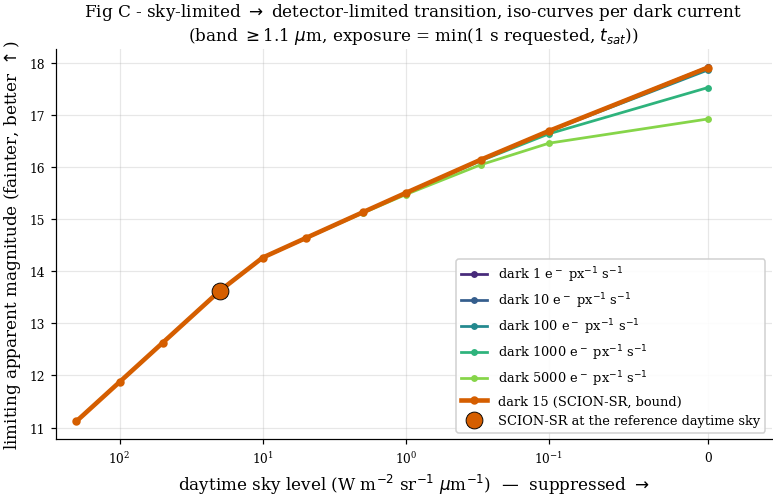

Iso-curve spread across the dark-current family: 0.00 mag at sky=200 (sky-limited, curves collapse)
                                          ->  1.00 mag at sky=0 (detector-limited, curves fan out)
At the reference daytime sky the exposure is SATURATION-CAPPED: t_used = 0.614 s (requested 1 s), limiting mag 13.62.


In [32]:
sky_axis = np.array([200, 100, 50, 20, 10, 5, 2, 1, 0.3, 0.1, 0.0])
fam_cols = plt.cm.viridis(np.linspace(0.12, 0.82, len(DARK_FAMILY_E_S)))

fig, ax = plt.subplots()
for dk, col in zip(DARK_FAMILY_E_S, fam_cols):
    lm = np.array([limiting_mag_capped(OPERATIONAL_BAND_UM, sv, T_MAX_REQUEST_S, SCION["full_well"], dark_e_s=dk)[0]
                   for sv in sky_axis])
    ax.plot(sky_axis, lm, "o-", color=col, lw=1.8, ms=3.5, label=r"dark %g e$^-$ px$^{-1}$ s$^{-1}$" % dk)
lm_marked = np.array([limiting_mag_capped(OPERATIONAL_BAND_UM, sv, T_MAX_REQUEST_S, SCION["full_well"])[0]
                      for sv in sky_axis])
ax.plot(sky_axis, lm_marked, "o-", color=CBB["vermilion"], lw=3.0, ms=4.5, zorder=5,
        label=r"dark %g (%s, bound)" % (SCION["dark_e_s"], SCION["label"]))
m_ref, t_used_ref, capped_ref = limiting_mag_capped(OPERATIONAL_BAND_UM, REF_SKY_DAYTIME, T_MAX_REQUEST_S, SCION["full_well"])
ax.plot(REF_SKY_DAYTIME, m_ref, "o", color=CBB["vermilion"], ms=11, mec=CBB["black"], mew=0.6, zorder=6,
        label="%s at the reference daytime sky" % SCION["label"])
ax.set_xscale("symlog", linthresh=0.1); ax.invert_xaxis(); ax.set_xlim(sky_axis.max()*1.4, -0.04)
ax.set_xlabel(r"daytime sky level (W m$^{-2}$ sr$^{-1}$ $\mu$m$^{-1}$)  —  suppressed $\rightarrow$")
ax.set_ylabel("limiting apparent magnitude (fainter, better $\\uparrow$)")
ax.set_title("Fig C - sky-limited $\\rightarrow$ detector-limited transition, iso-curves per dark current\n"
             r"(band $\geq$1.1 $\mu$m, exposure = min(%g s requested, $t_{sat}$))" % T_MAX_REQUEST_S)
ax.legend(loc="lower right", fontsize=8.5)
plt.show()

spread_bright = max(limiting_mag_capped(OPERATIONAL_BAND_UM, sky_axis[0], T_MAX_REQUEST_S, SCION["full_well"], dark_e_s=dk)[0]
                    for dk in DARK_FAMILY_E_S) - \
                min(limiting_mag_capped(OPERATIONAL_BAND_UM, sky_axis[0], T_MAX_REQUEST_S, SCION["full_well"], dark_e_s=dk)[0]
                    for dk in DARK_FAMILY_E_S)
spread_dark   = max(limiting_mag_capped(OPERATIONAL_BAND_UM, 0.0, T_MAX_REQUEST_S, SCION["full_well"], dark_e_s=dk)[0]
                    for dk in DARK_FAMILY_E_S) - \
                min(limiting_mag_capped(OPERATIONAL_BAND_UM, 0.0, T_MAX_REQUEST_S, SCION["full_well"], dark_e_s=dk)[0]
                    for dk in DARK_FAMILY_E_S)
print("Iso-curve spread across the dark-current family: %.2f mag at sky=%g (sky-limited, curves collapse)"
      % (spread_bright, sky_axis[0]))
print("                                          ->  %.2f mag at sky=0 (detector-limited, curves fan out)" % spread_dark)
print("At the reference daytime sky the exposure is %s: t_used = %.3g s (requested %g s), limiting mag %.2f."
      % ("SATURATION-CAPPED" if capped_ref else "not capped", t_used_ref, T_MAX_REQUEST_S, m_ref))

## §6.6 Parameter ranges swept, and SCION-SR's operating point

The families below are the **competitor space** this section spans. There is **no competitor row** — no
specific system is named, marked, or tabulated anywhere in §6; the only identified point is SCION-SR's.

In [33]:
sweep_rows = [
    ("read noise (e- RMS)",              "%g - %g" % (READ_FAMILY_E[0], READ_FAMILY_E[-1]),
     "%g" % SCION["read_e"],             "config; published as an UPPER BOUND"),
    ("dark current (e-/px/s)",           "%g - %g" % (DARK_FAMILY_E_S[0], DARK_FAMILY_E_S[-1]),
     "%g" % SCION["dark_e_s"],           "config; UPPER BOUND; deep TEC (-70/-75 C)"),
    ("full well (e-/px)",                "%.0e - %.0e" % (WELL_FAMILY_E[0], WELL_FAMILY_E[-1]),
     "%.0e" % SCION["full_well"],        "config; %.0f%% treated as usable [IDEALIZATION]" % (100*WELL_USABLE_FRACTION)),
    ("QE(lambda)",                       "single curve (not swept)",
     "VISGaAs, peak %.2f" % QE_VISGAAS.max(), "PLACEHOLDER parametric shape; pending measured curve"),
    ("pixel pitch (um)",                 "fixed",
     "%g" % SCION["pitch_um"],           "config; sets the per-pixel sky solid angle"),
    ("daytime sky (W/m^2/sr/um)",        "0 - %g" % 200,
     "%g (reference)" % REF_SKY_DAYTIME, "PLACEHOLDER levels; NO solar-elevation mapping"),
    ("integration time (s)",             "%.0e - %.0e requested" % (T_AXIS_S[0], T_AXIS_S[-1]),
     "cap %.3g s at ref sky" % ts_scion, "cap = usable well / per-pixel fill rate"),
    ("band lower cutoff (um)",           "%.2f - %.2f" % (0.40, 1.41),
     "%.2f (adopted)" % OPERATIONAL_BAND_UM, "Waldmann >=1.1 um operational reference"),
]
sweep_tbl = pd.DataFrame(sweep_rows, columns=["parameter", "range swept (competitor space)",
                                              "SCION-SR operating point", "source / flag"]).set_index("parameter")
print("Swept parameter space and the single marked operating point (SNR_DETECT=%d, range_ref=%g km):"
      % (SNR_DETECT, RANGE_REF_KM))
print(sweep_tbl.to_string())
print("\nNo competitor system is represented in this table or in any figure of this section.")

Swept parameter space and the single marked operating point (SNR_DETECT=5, range_ref=1000 km):
                          range swept (competitor space) SCION-SR operating point                                         source / flag
parameter                                                                                                                              
read noise (e- RMS)                              5 - 100                       30                   config; published as an UPPER BOUND
dark current (e-/px/s)                          1 - 5000                       15             config; UPPER BOUND; deep TEC (-70/-75 C)
full well (e-/px)                          1e+04 - 1e+07                    1e+06         config; 100% treated as usable [IDEALIZATION]
QE(lambda)                      single curve (not swept)       VISGaAs, peak 0.85  PLACEHOLDER parametric shape; pending measured curve
pixel pitch (um)                                   fixed                       10        

## §6.7 NIR–SWIR color index (brief, secondary)

A **color observable** = magnitude difference between a NIR sub-band and a SWIR sub-band, **both inside the
VISGaAs good-QE region** (the visible is excluded because VISGaAs QE is poor there). It supports material
discrimination (a secondary application), not the §6 custody claim, and — like the band result — depends on
the placeholder QE. Illustrated with two toy material reflectance slopes.

In [34]:
def _band_flux(qe, lo, hi, refl):
    m = ((GRID_UM >= lo) & (GRID_UM <= hi)).astype(float)
    return np.trapz(E_tgt_m * refl * A_TEL * TAU_OPTICS * T_atm * lam_m/(H*C) * qe * m, lam_m)
ramp   = np.clip((GRID_UM - 0.9)/0.8, 0, 1)
panel  = 0.10 + 0.25*ramp        # illustrative: solar-panel-like, rising toward SWIR   [PLACEHOLDER]
body   = 0.30 - 0.12*ramp        # illustrative: body-like, falling toward SWIR         [PLACEHOLDER]
def nir_swir_color(refl):
    nir  = _band_flux(QE_VISGAAS, COLOR_NIR_UM[0],  COLOR_NIR_UM[1],  refl)
    swir = _band_flux(QE_VISGAAS, COLOR_SWIR_UM[0], COLOR_SWIR_UM[1], refl)
    return -2.5*np.log10(nir/swir)
print("NIR-SWIR color = m(%.1f-%.1f) - m(%.1f-%.1f), SCION-SR QE:" % (COLOR_NIR_UM+COLOR_SWIR_UM))
for name, refl in (("panel-like (rising)", panel), ("body-like (falling)", body)):
    print("  %-22s color = %+.3f mag" % (name, nir_swir_color(refl)))
print("=> distinct materials separate in the NIR-SWIR color; illustrative only (placeholder QE + reflectances).")

NIR-SWIR color = m(1.0-1.2) - m(1.4-1.7), SCION-SR QE:
  panel-like (rising)    color = +0.421 mag
  body-like (falling)    color = -0.597 mag
=> distinct materials separate in the NIR-SWIR color; illustrative only (placeholder QE + reflectances).
